
NSE DAILY RETURNS STATISTICS
                   Mean  Standard Deviation  Skewness   Kurtosis
^NSEI          0.000568            0.008786 -0.361435   4.283443
RELIANCE.NS    0.000604            0.014173  0.196660   2.809449
TCS.NS         0.000211            0.012992  0.127499   2.562334
INFY.NS        0.000440            0.015067 -0.186322   3.838863
HDFCBANK.NS    0.000425            0.013354  0.081990   5.756245
ICICIBANK.NS   0.000877            0.013879  0.826138   9.424728
LT.NS          0.001073            0.015200 -0.214954   5.850605
ITC.NS         0.000838            0.012522  0.323128   3.327425
SBIN.NS        0.001222            0.016460  0.008638   8.669389
BHARTIARTL.NS  0.001232            0.014190  0.161916   1.751723
HINDUNILVR.NS  0.000158            0.012632  0.094496   3.225802
IDEA.NS        0.000750            0.037422  0.814931   7.377200
YESBANK.NS     0.000555            0.024937  1.460684   9.183042
SUZLON.NS      0.002352            0.033266  0.797591   2.83

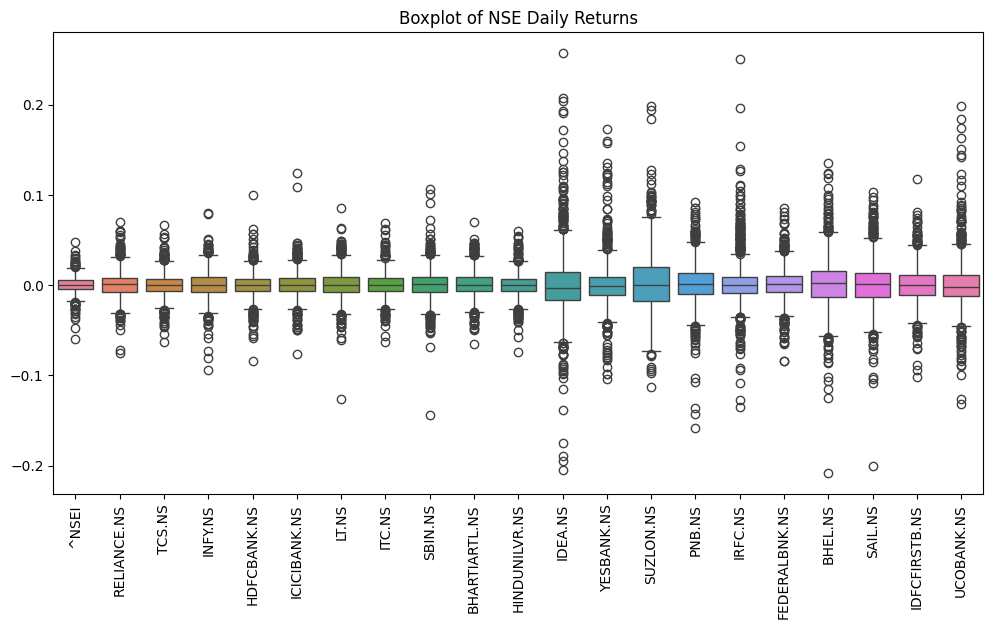

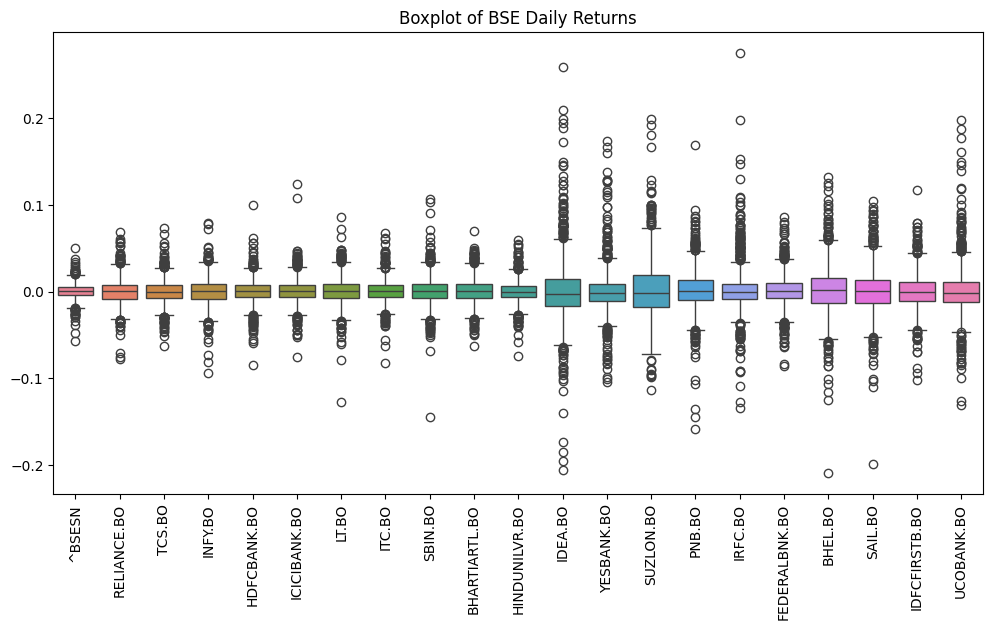

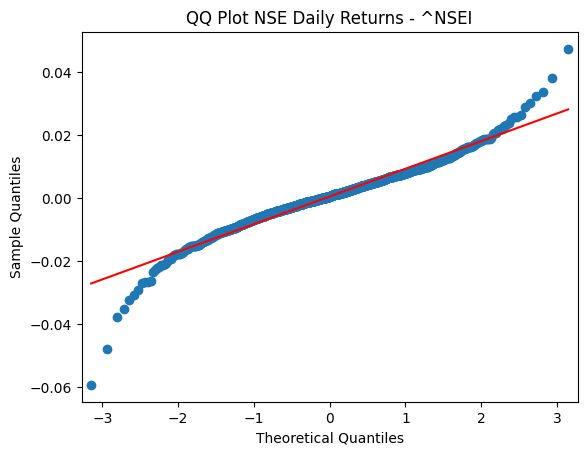

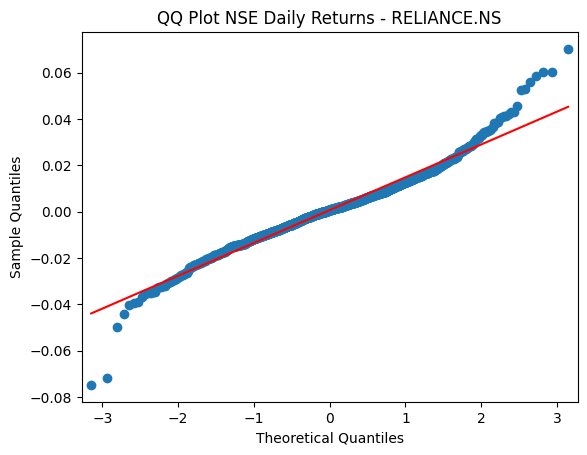

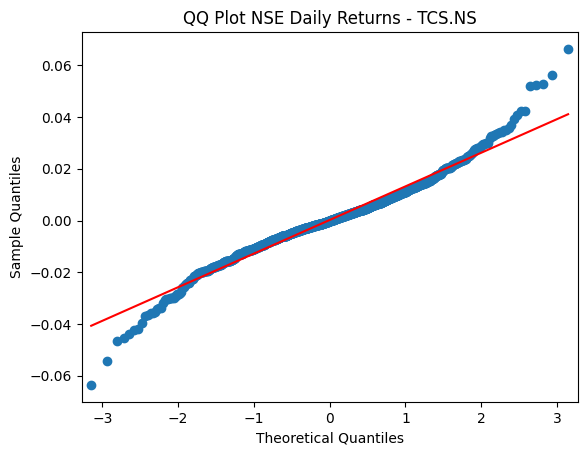

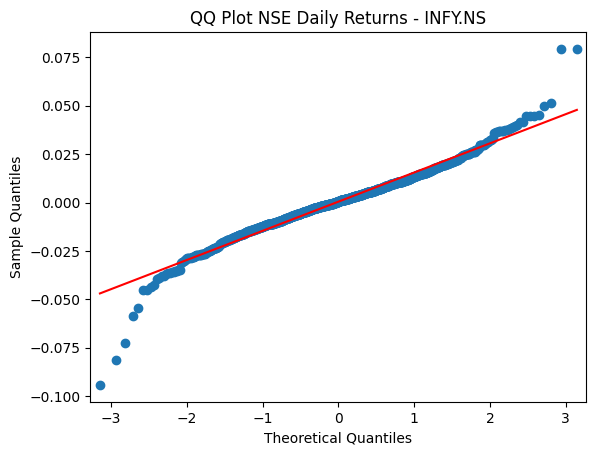

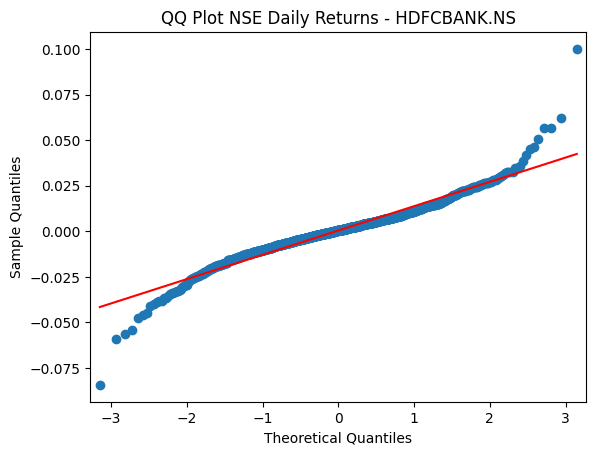

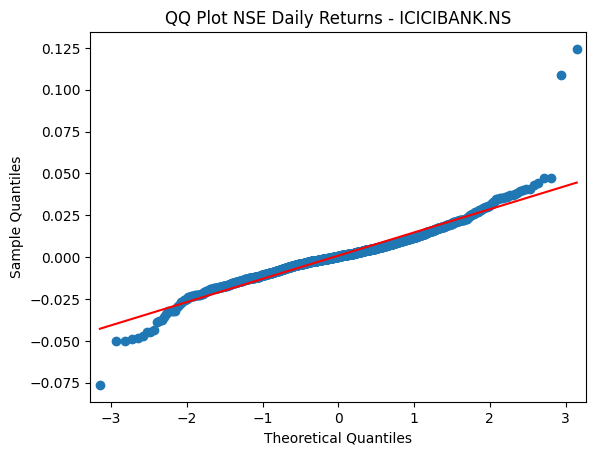

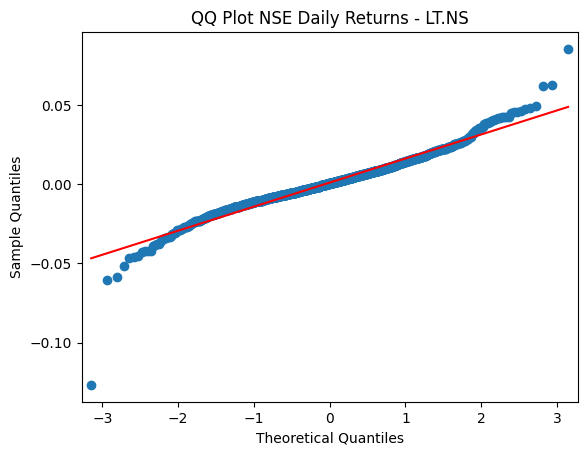

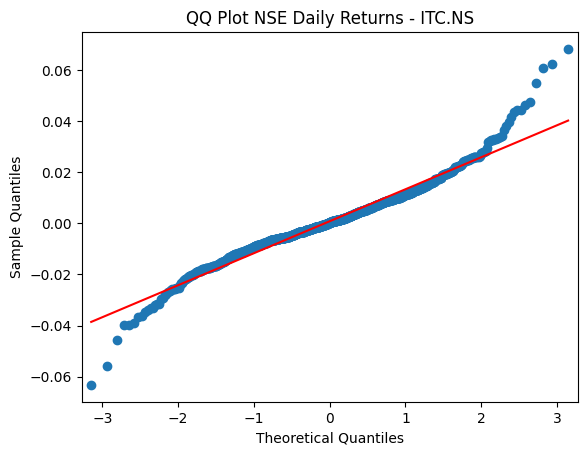

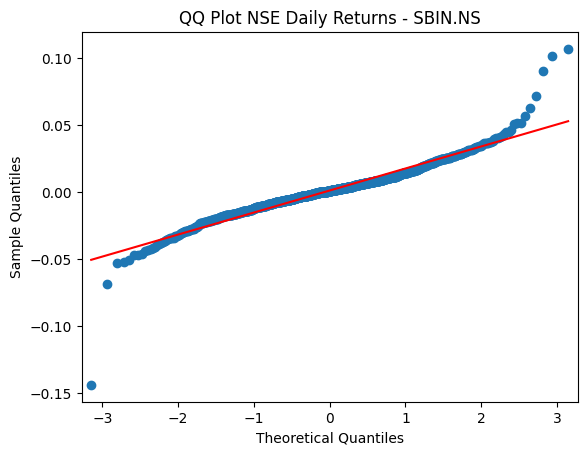

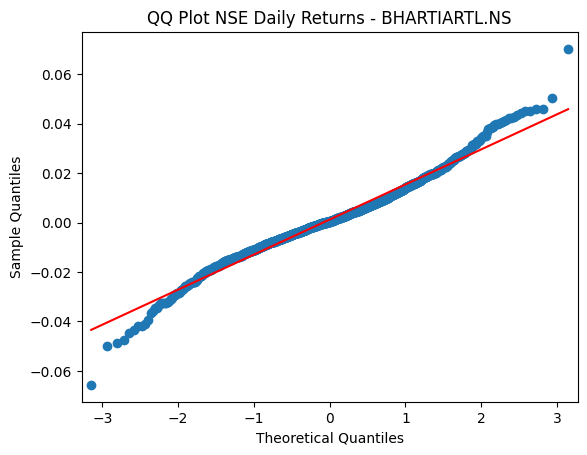

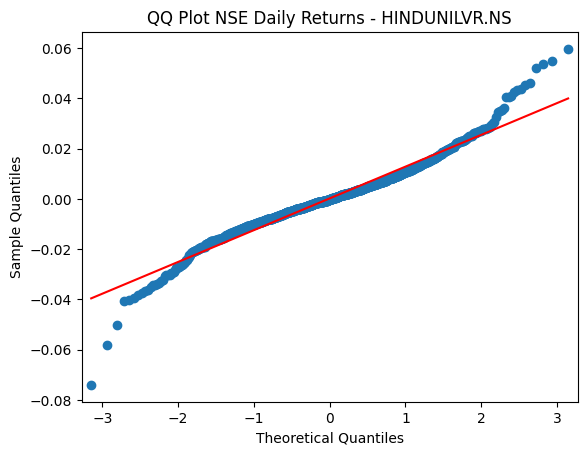

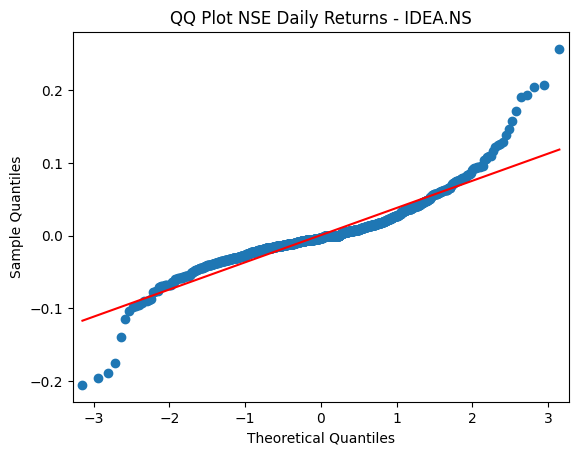

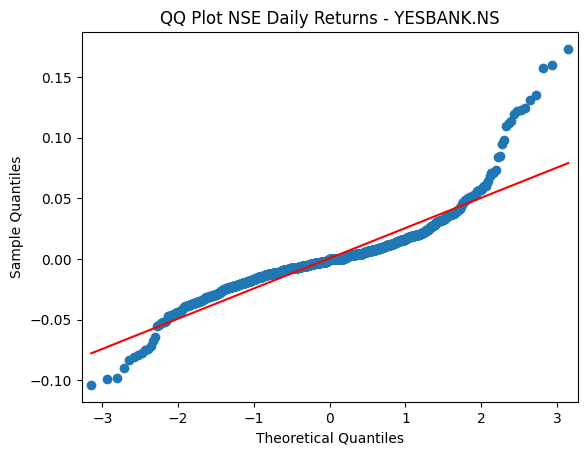

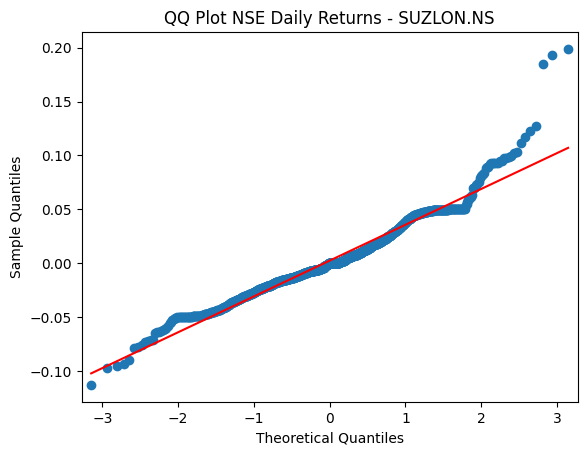

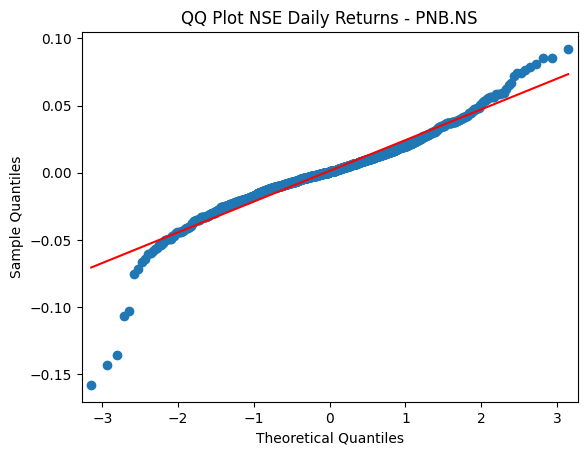

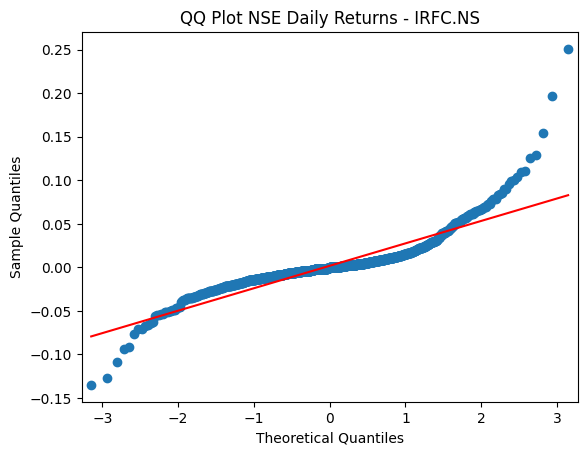

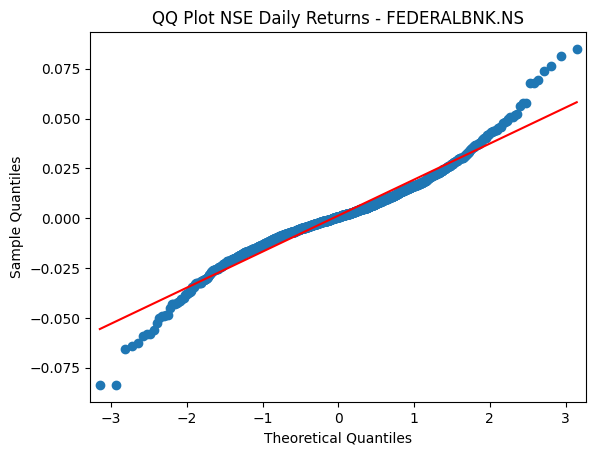

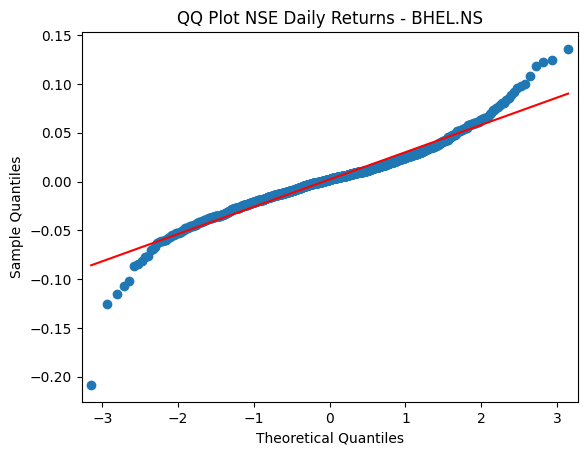

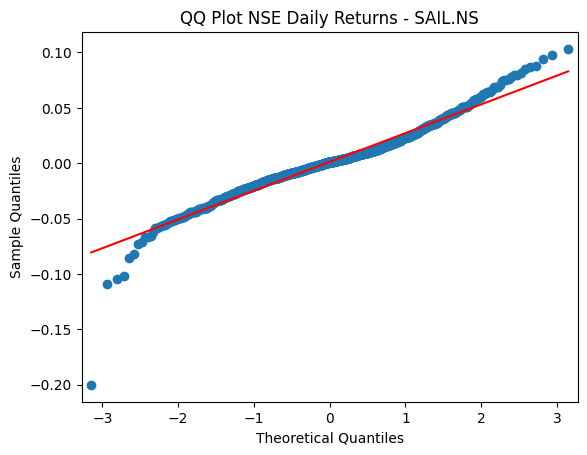

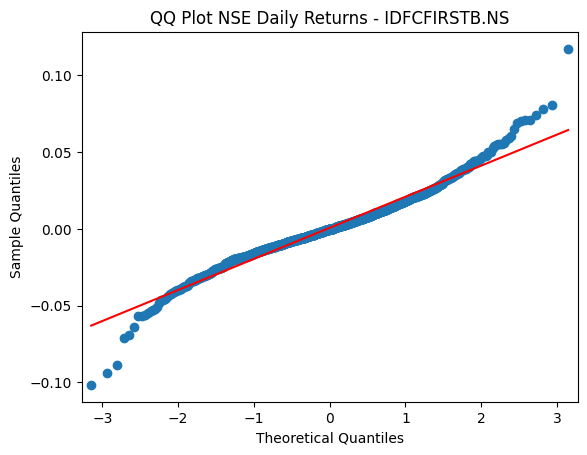

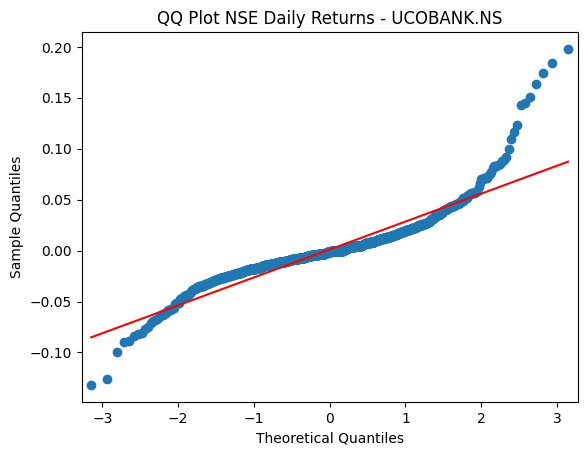

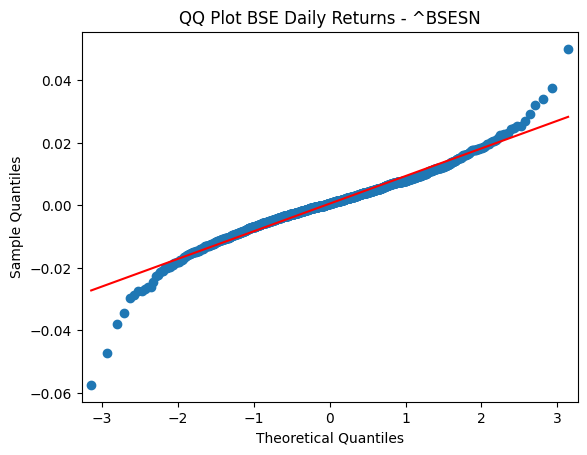

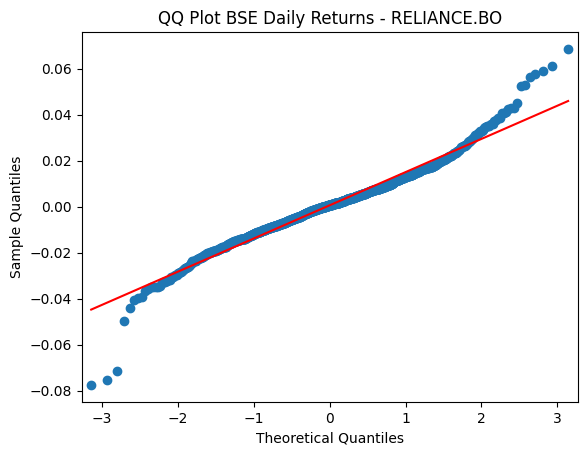

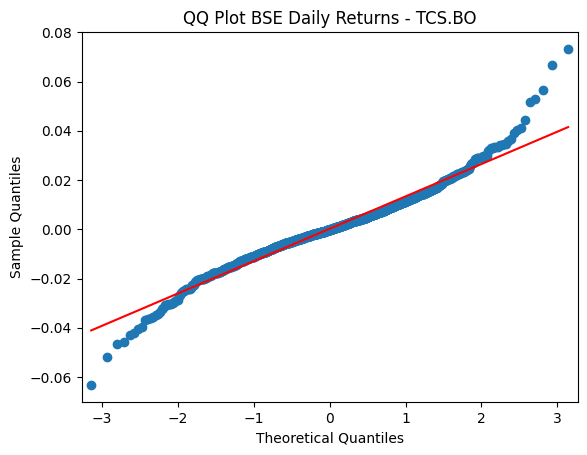

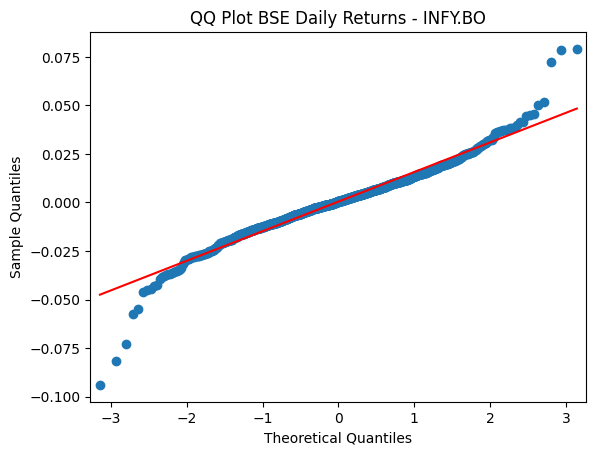

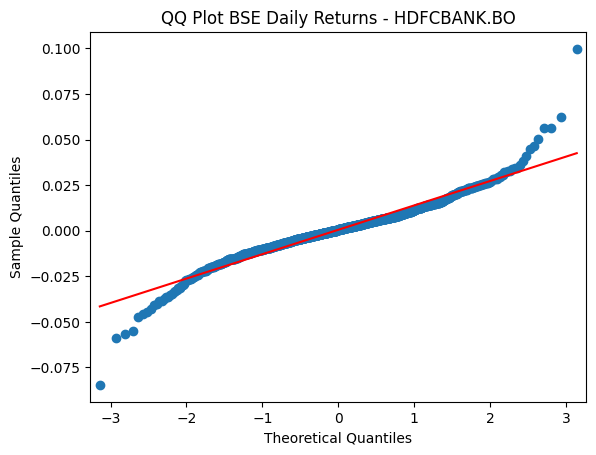

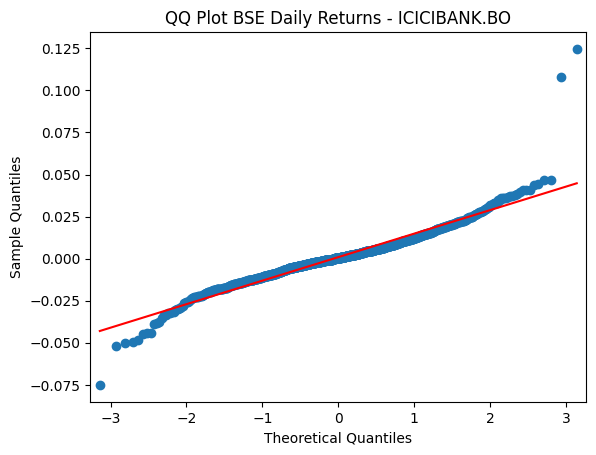

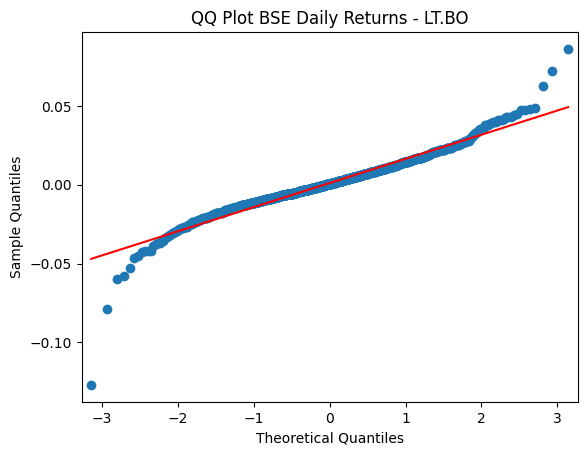

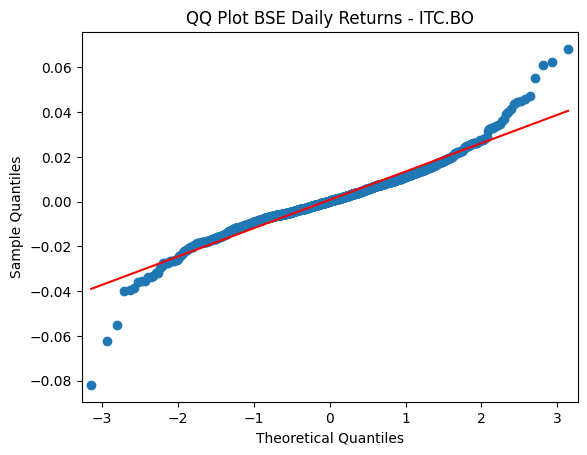

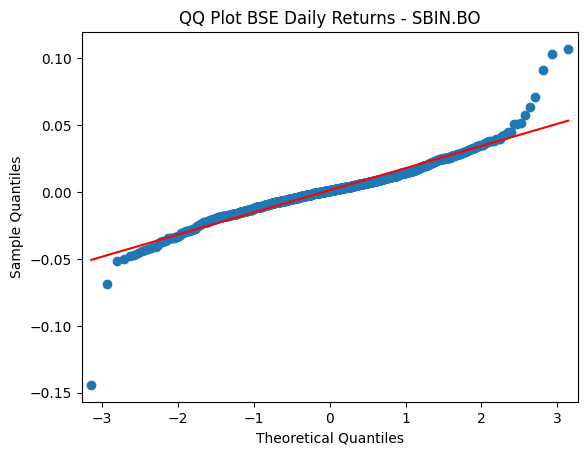

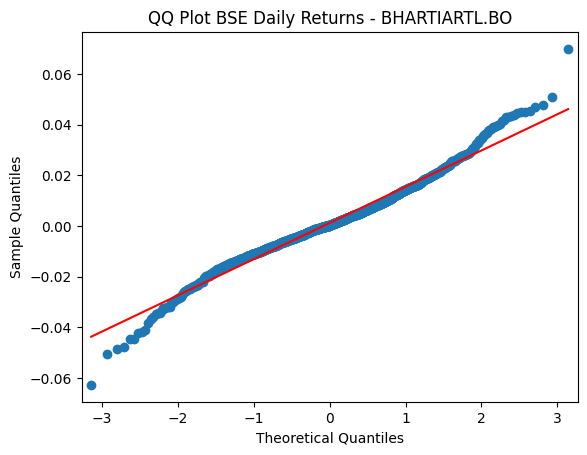

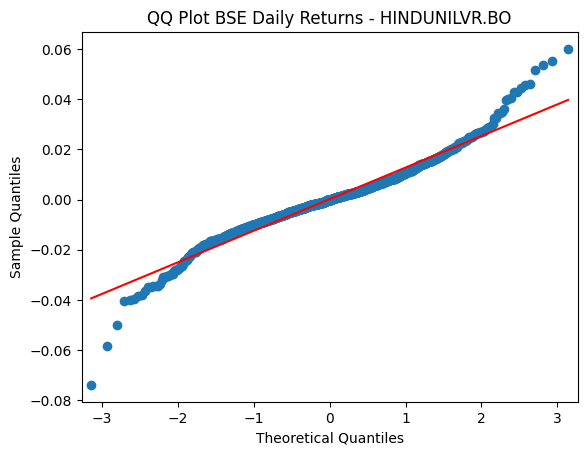

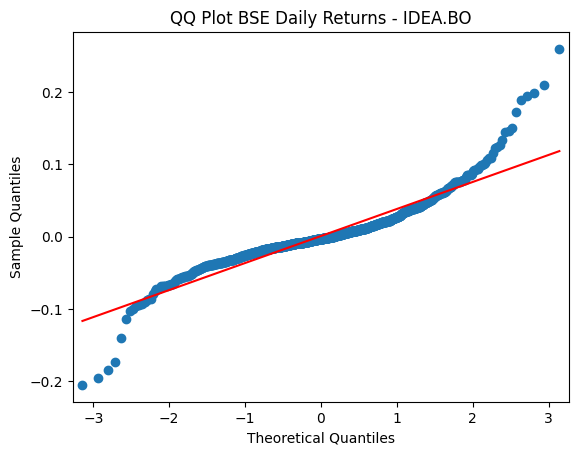

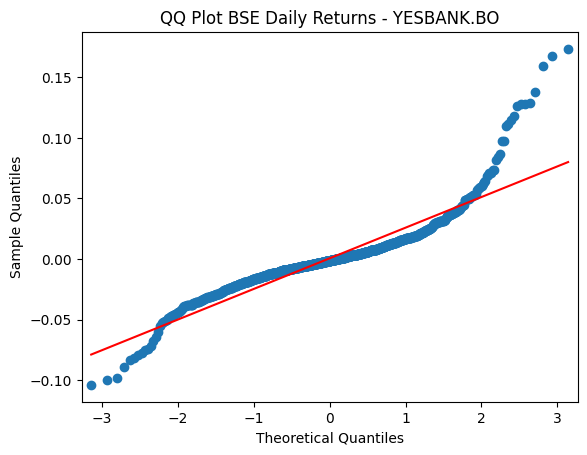

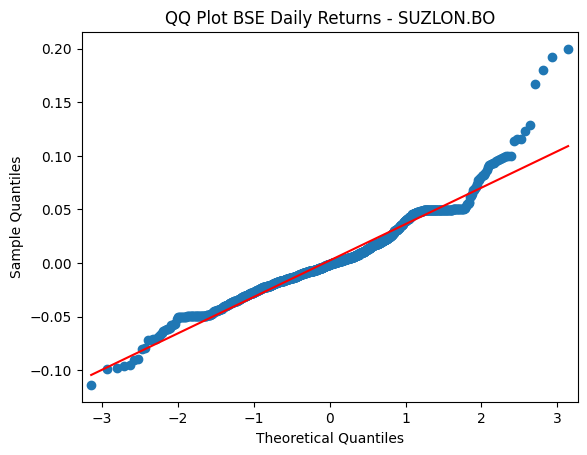

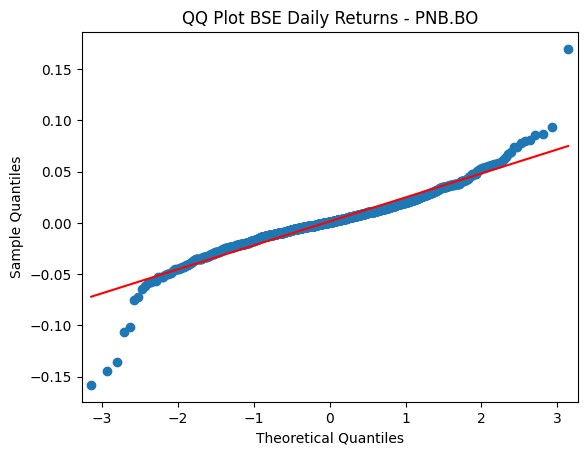

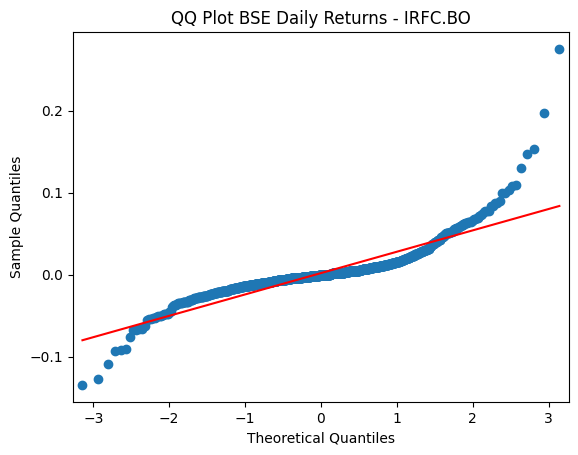

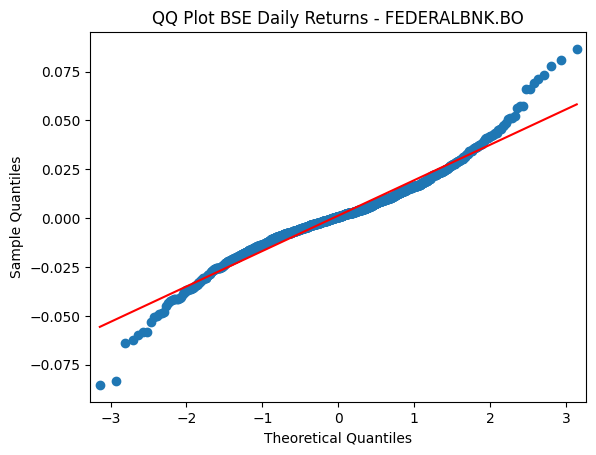

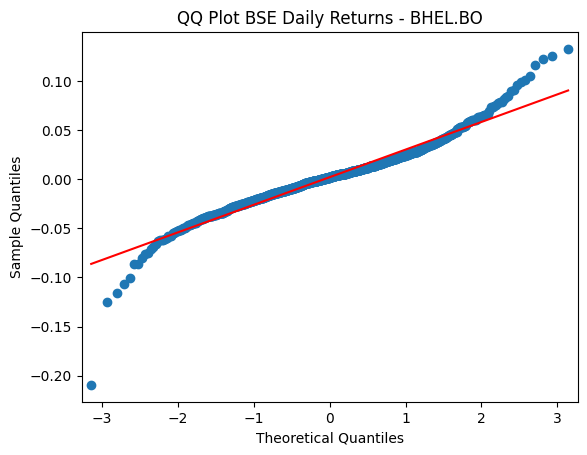

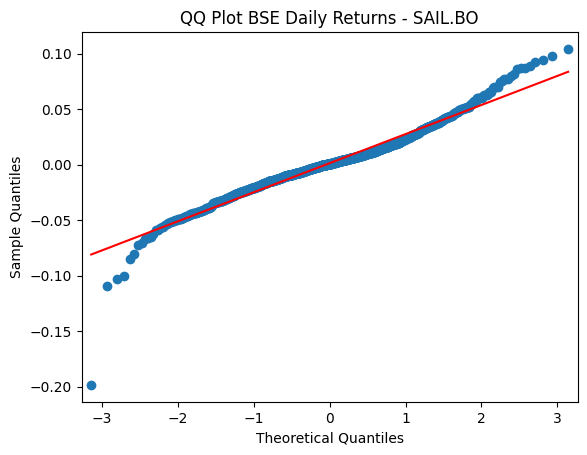

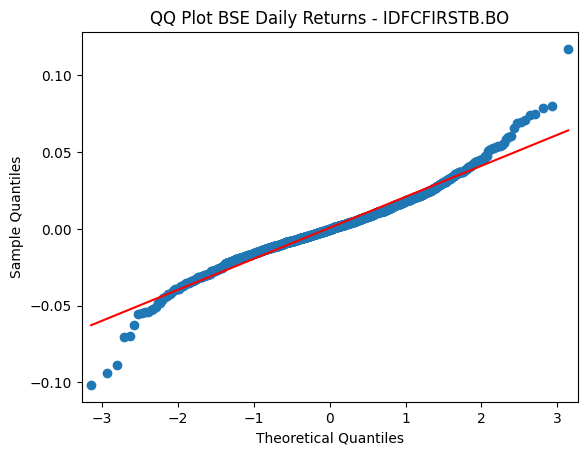

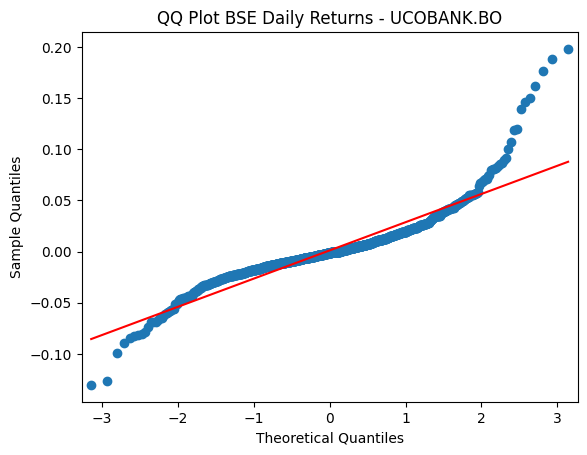


NSE DAILY RETURNS KS TEST
               KS Statistic       p-value
^NSEI              0.055587  1.052896e-03
RELIANCE.NS        0.056977  7.189270e-04
TCS.NS             0.055034  1.222230e-03
INFY.NS            0.045887  1.161385e-02
HDFCBANK.NS        0.067134  3.320656e-05
ICICIBANK.NS       0.070123  1.220587e-05
LT.NS              0.054792  1.304028e-03
ITC.NS             0.057707  5.860695e-04
SBIN.NS            0.072542  5.260267e-06
BHARTIARTL.NS      0.053360  1.902707e-03
HINDUNILVR.NS      0.062141  1.603446e-04
IDEA.NS            0.113000  5.708699e-14
YESBANK.NS         0.119680  1.272801e-15
SUZLON.NS          0.076336  1.325646e-06
PNB.NS             0.065835  5.061902e-05
IRFC.NS            0.158154  5.181061e-27
FEDERALBNK.NS      0.065476  5.679038e-05
BHEL.NS            0.064142  8.656861e-05
SAIL.NS            0.073119  4.284061e-06
IDFCFIRSTB.NS      0.056333  8.588654e-04
UCOBANK.NS         0.112381  8.033367e-14

BSE DAILY RETURNS KS TEST
               KS Stat

In [15]:
# MA374 Financial Engineering Lab
# Question 1: Daily Returns Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from scipy.stats import kstest, shapiro
import statsmodels.api as sm


# -----------------------------------------
# Load the datasets
# -----------------------------------------

nse = pd.read_csv("nsedata1.csv")
bse = pd.read_csv("bsedata1.csv")

# Convert Date column
nse['Date'] = pd.to_datetime(nse['Date'])
bse['Date'] = pd.to_datetime(bse['Date'])

# Set Date as index
nse.set_index('Date', inplace=True)
bse.set_index('Date', inplace=True)


# -----------------------------------------
# Compute Daily Returns
# -----------------------------------------

# Daily return = (P_t - P_{t-1}) / P_{t-1}

nse_returns = nse.pct_change().dropna()
bse_returns = bse.pct_change().dropna()


# -----------------------------------------
# Helper Functions
# -----------------------------------------

def descriptive_statistics(returns):

    stats = pd.DataFrame(columns=[
        "Mean",
        "Standard Deviation",
        "Skewness",
        "Kurtosis"
    ])

    for col in returns.columns:

        r = returns[col].dropna()

        stats.loc[col] = [
            r.mean(),
            r.std(),
            skew(r),
            kurtosis(r)
        ]

    return stats


def ks_test(returns):

    results = {}

    for col in returns.columns:

        r = returns[col].dropna()

        mu = r.mean()
        sigma = r.std()

        stat, p_value = kstest(r, 'norm', args=(mu, sigma))

        results[col] = (stat, p_value)

    return pd.DataFrame(results,
                        index=["KS Statistic", "p-value"]).T


def shapiro_test(returns):

    results = {}

    for col in returns.columns:

        r = returns[col].dropna()

        stat, p_value = shapiro(r)

        results[col] = (stat, p_value)

    return pd.DataFrame(results,
                        index=["Shapiro Statistic", "p-value"]).T


def mle_estimates(returns):

    results = pd.DataFrame(columns=[
        "Mean (MLE)",
        "Variance (MLE)",
        "95% CI Lower",
        "95% CI Upper"
    ])

    for col in returns.columns:

        r = returns[col].dropna()

        n = len(r)

        mu = r.mean()
        variance = r.var()
        sigma = r.std()

        ci_lower = mu - 1.96 * sigma / np.sqrt(n)
        ci_upper = mu + 1.96 * sigma / np.sqrt(n)

        results.loc[col] = [
            mu,
            variance,
            ci_lower,
            ci_upper
        ]

    return results


# =========================================
# Descriptive Statistics
# =========================================

print("\n===============================")
print("NSE DAILY RETURNS STATISTICS")
print("===============================")

print(descriptive_statistics(nse_returns))


print("\n===============================")
print("BSE DAILY RETURNS STATISTICS")
print("===============================")

print(descriptive_statistics(bse_returns))


# =========================================
# Boxplots
# =========================================

plt.figure(figsize=(12,6))
sns.boxplot(data=nse_returns)
plt.title("Boxplot of NSE Daily Returns")
plt.xticks(rotation=90)
plt.show()


plt.figure(figsize=(12,6))
sns.boxplot(data=bse_returns)
plt.title("Boxplot of BSE Daily Returns")
plt.xticks(rotation=90)
plt.show()


# =========================================
# QQ Plots
# =========================================

for col in nse_returns.columns:

    sm.qqplot(nse_returns[col], line='s')
    plt.title(f"QQ Plot NSE Daily Returns - {col}")
    plt.show()


for col in bse_returns.columns:

    sm.qqplot(bse_returns[col], line='s')
    plt.title(f"QQ Plot BSE Daily Returns - {col}")
    plt.show()


# =========================================
# Kolmogorov-Smirnov Test
# =========================================

print("\n===============================")
print("NSE DAILY RETURNS KS TEST")
print("===============================")

print(ks_test(nse_returns))


print("\n===============================")
print("BSE DAILY RETURNS KS TEST")
print("===============================")

print(ks_test(bse_returns))


# =========================================
# Shapiro-Wilk Test
# =========================================

print("\n===============================")
print("NSE DAILY RETURNS SHAPIRO TEST")
print("===============================")

print(shapiro_test(nse_returns))


print("\n===============================")
print("BSE DAILY RETURNS SHAPIRO TEST")
print("===============================")

print(shapiro_test(bse_returns))


# =========================================
# Maximum Likelihood Estimates
# =========================================

print("\n===============================")
print("NSE DAILY RETURNS MLE ESTIMATES")
print("===============================")

print(mle_estimates(nse_returns))


print("\n===============================")
print("BSE DAILY RETURNS MLE ESTIMATES")
print("===============================")

print(mle_estimates(bse_returns))


NSE LOG RETURNS STATISTICS
                   Mean  Standard Deviation  Skewness   Kurtosis
^NSEI          0.000529            0.008797 -0.443730   4.502435
RELIANCE.NS    0.000503            0.014152  0.094678   2.846177
TCS.NS         0.000126            0.012984  0.039051   2.546115
INFY.NS        0.000326            0.015091 -0.320098   4.103849
HDFCBANK.NS    0.000336            0.013351 -0.071106   5.598013
ICICIBANK.NS   0.000782            0.013801  0.615518   8.192156
LT.NS          0.000957            0.015223 -0.404787   6.891390
ITC.NS         0.000759            0.012492  0.225571   3.253711
SBIN.NS        0.001086            0.016463 -0.269362   9.838979
BHARTIARTL.NS  0.001131            0.014162  0.082469   1.762325
HINDUNILVR.NS  0.000078            0.012628 -0.005290   3.313712
IDEA.NS        0.000061            0.037055  0.322367   7.184049
YESBANK.NS     0.000251            0.024545  1.136446   7.956804
SUZLON.NS      0.001807            0.032832  0.603159   2.1588

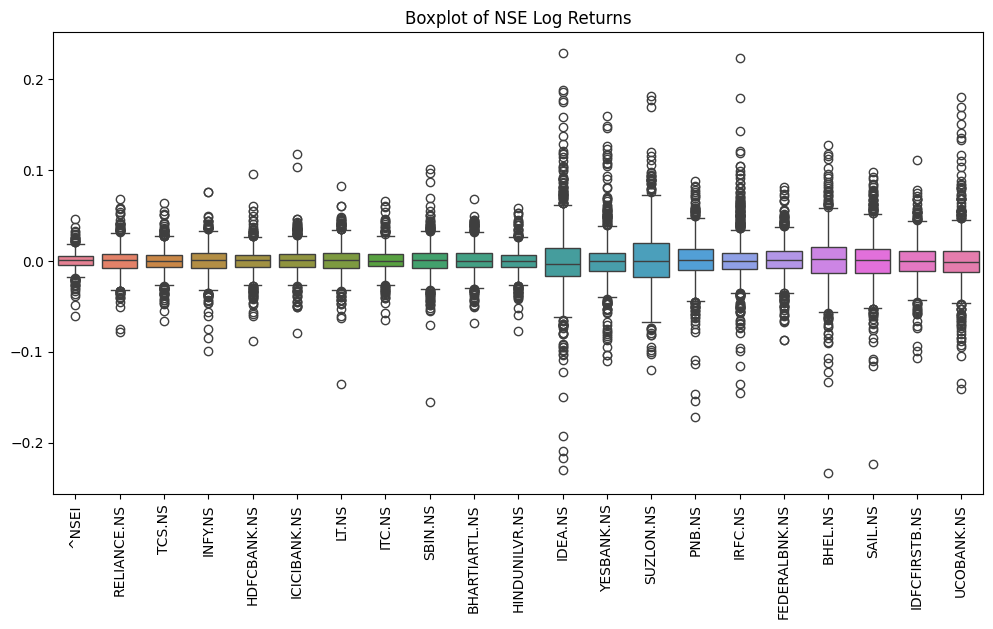

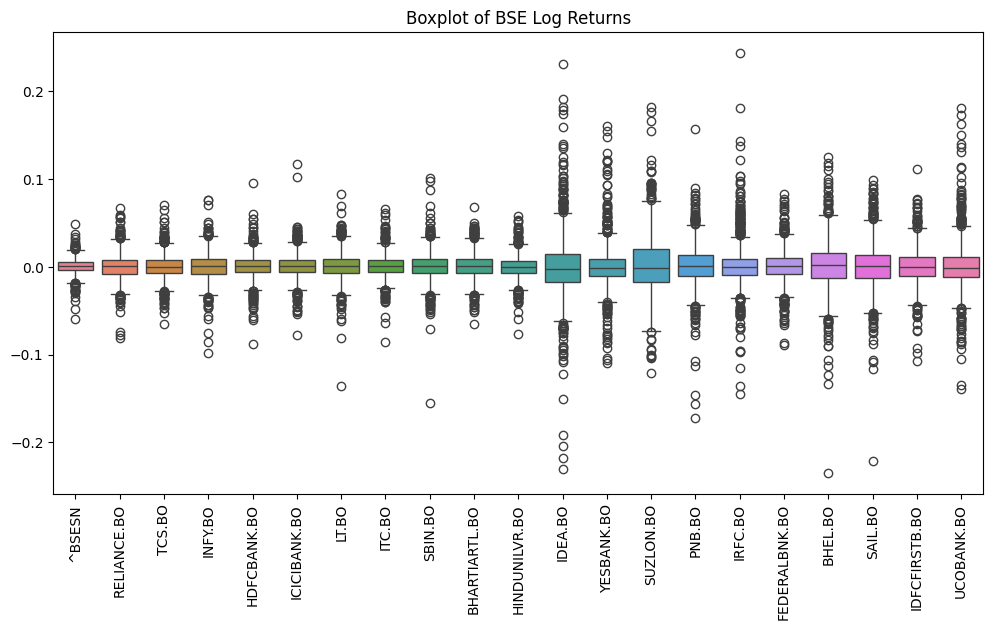

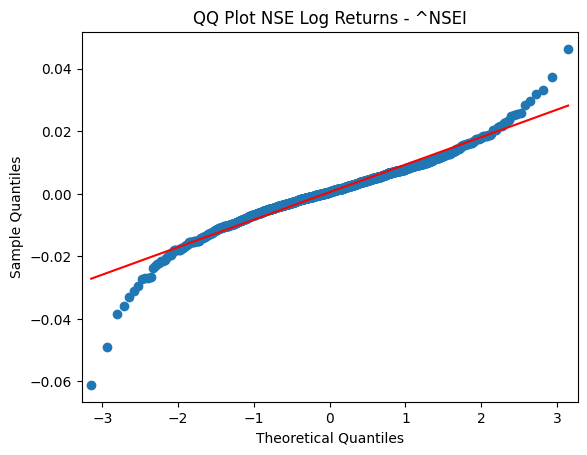

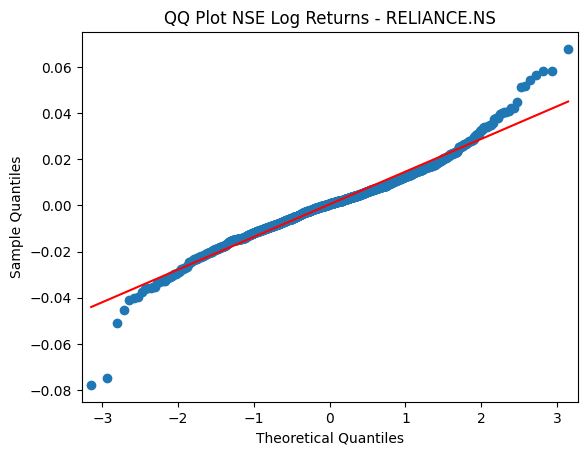

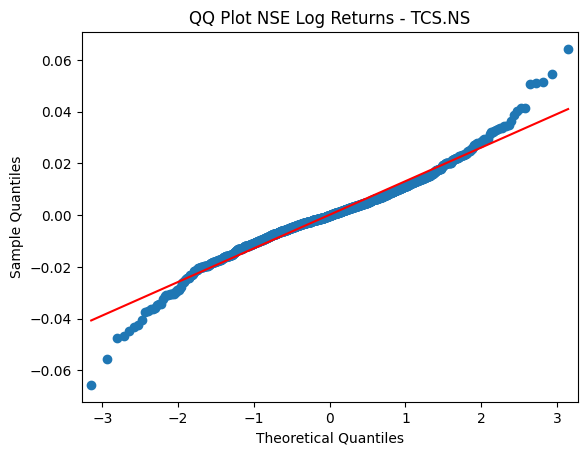

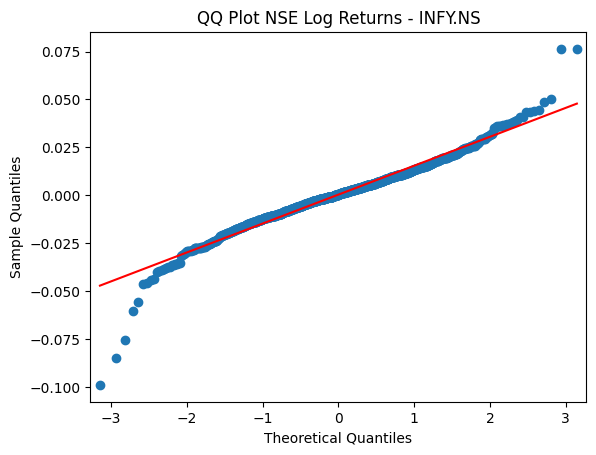

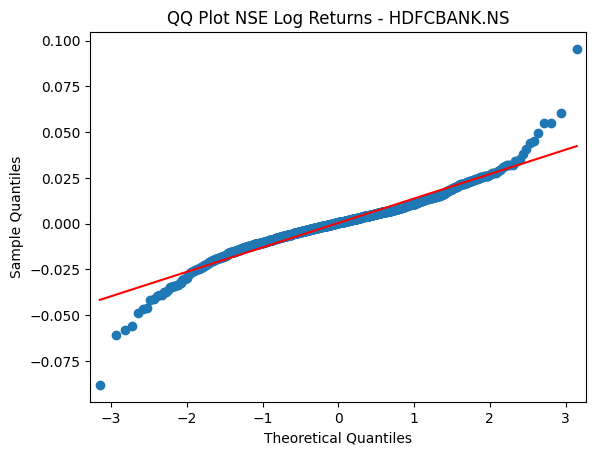

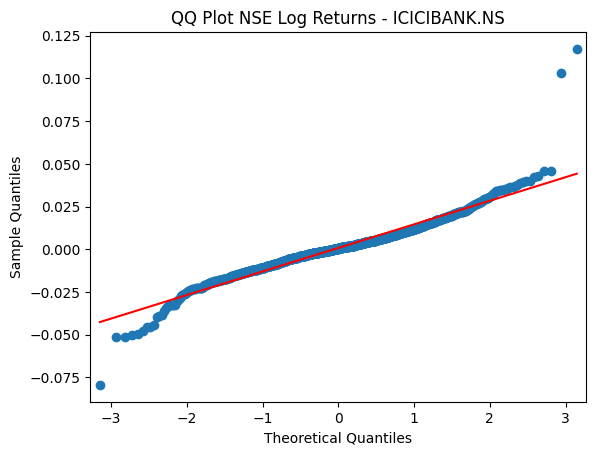

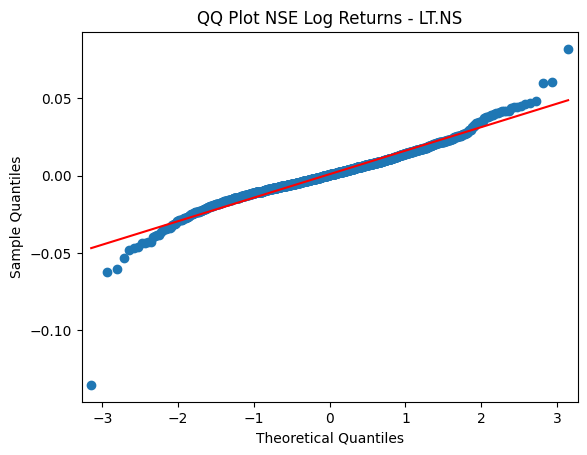

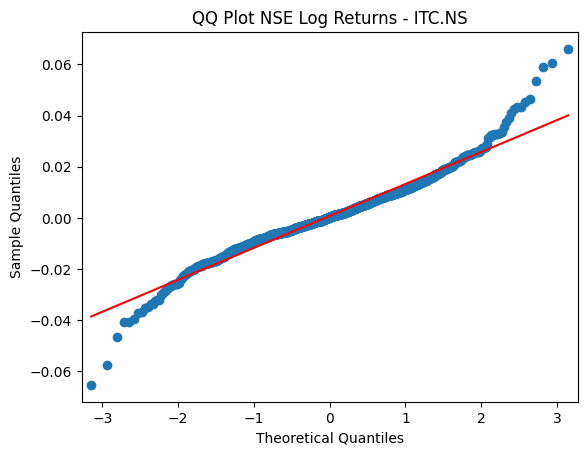

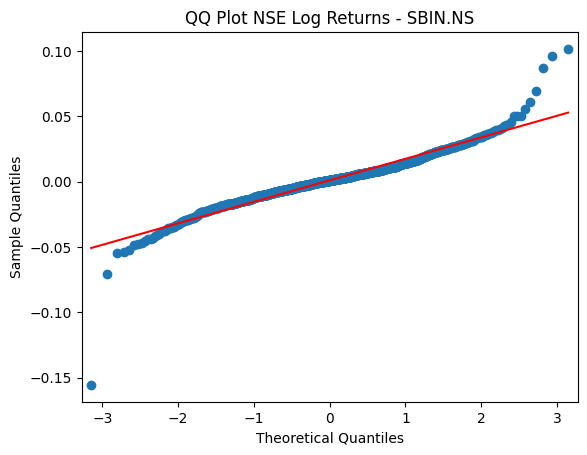

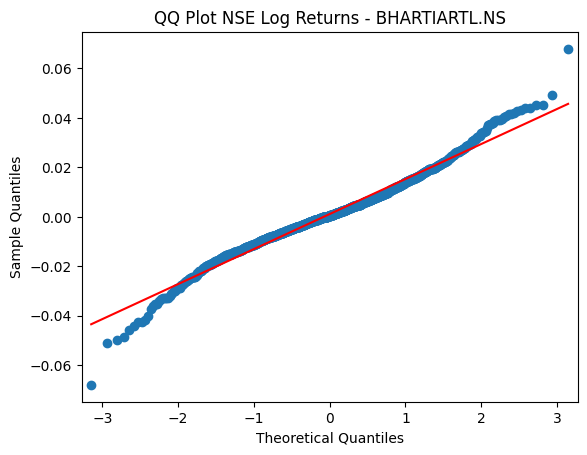

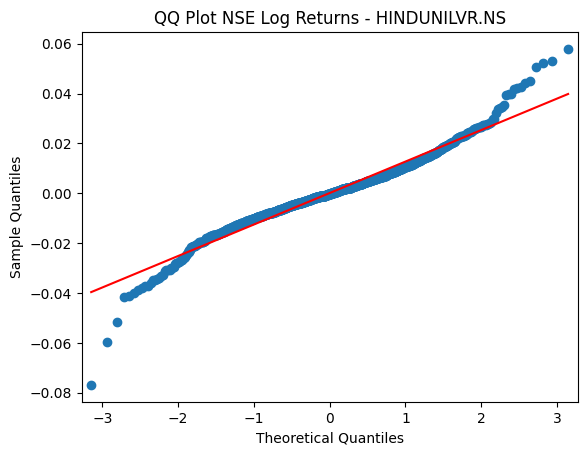

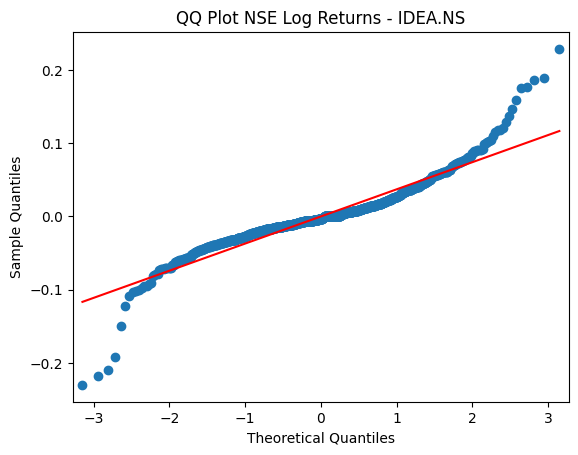

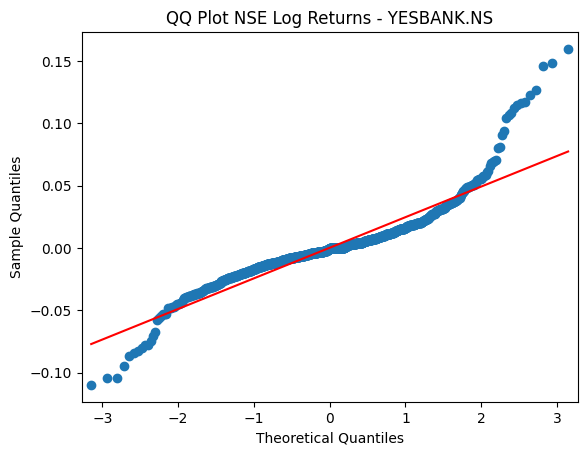

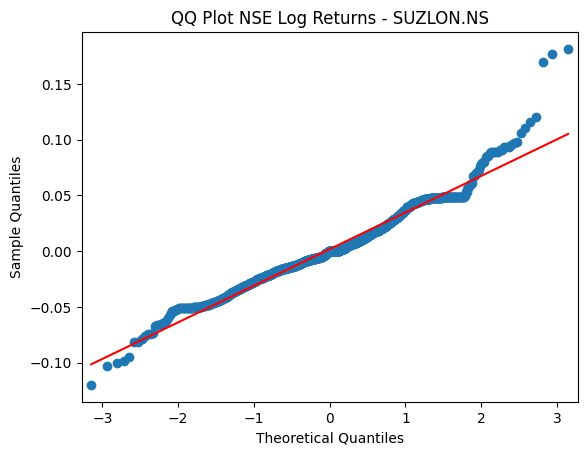

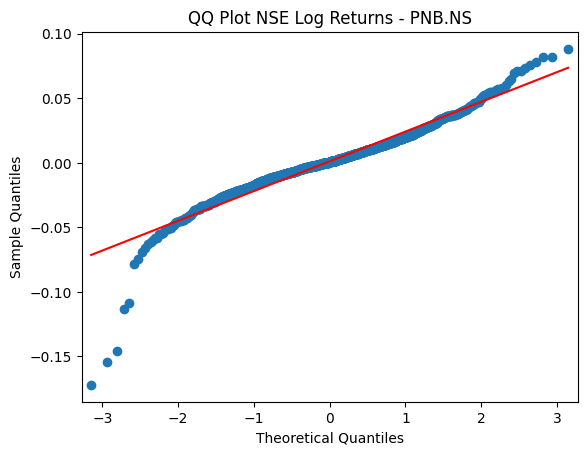

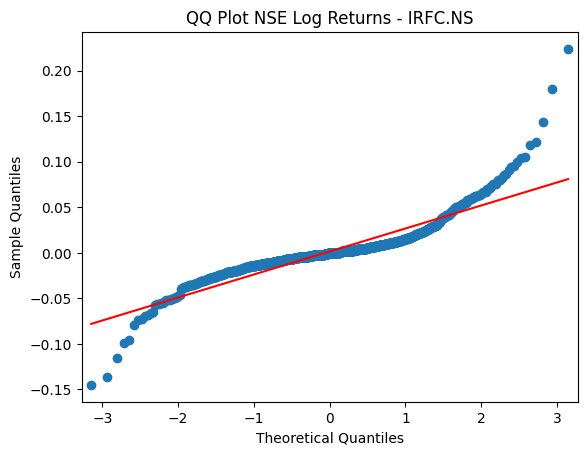

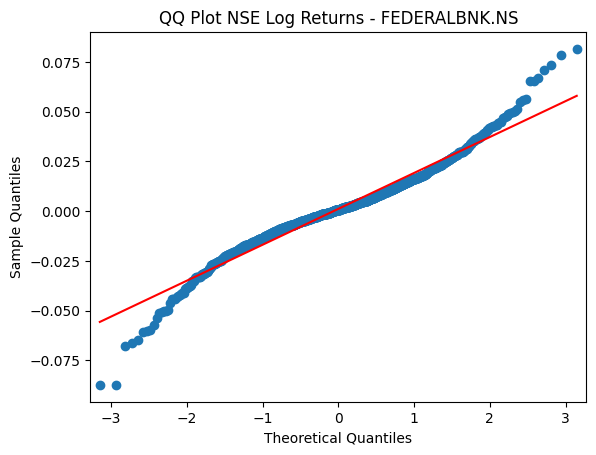

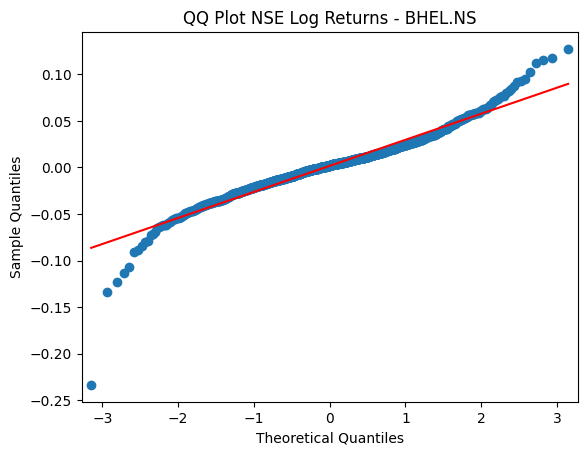

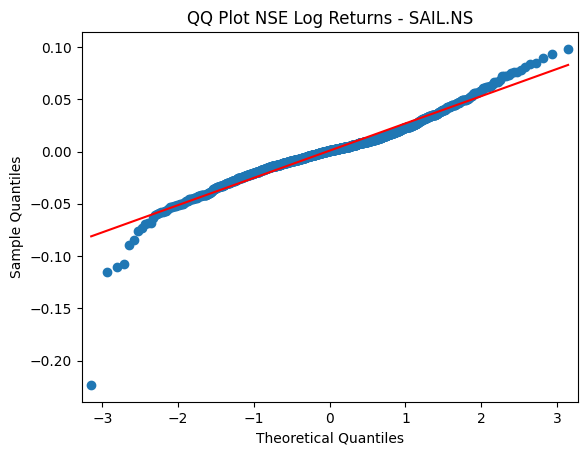

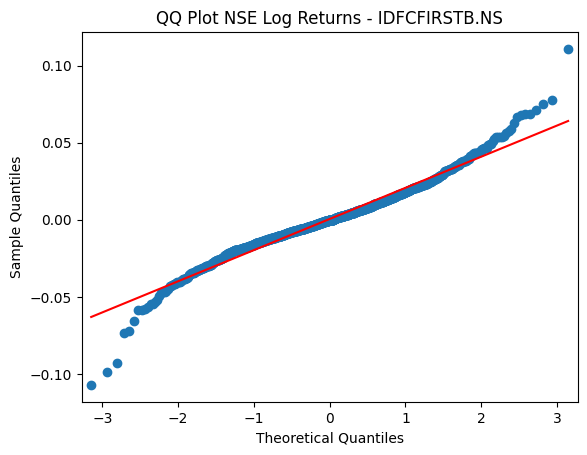

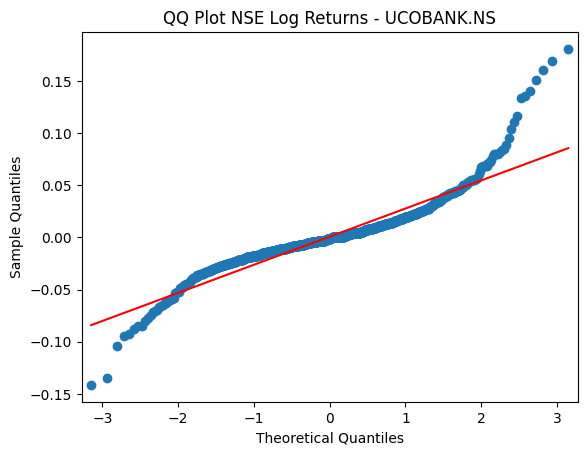

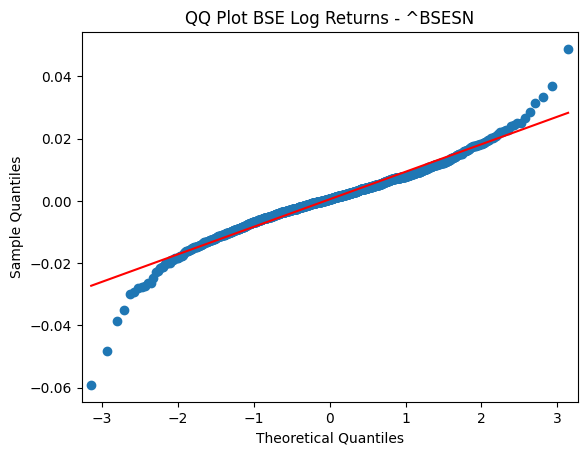

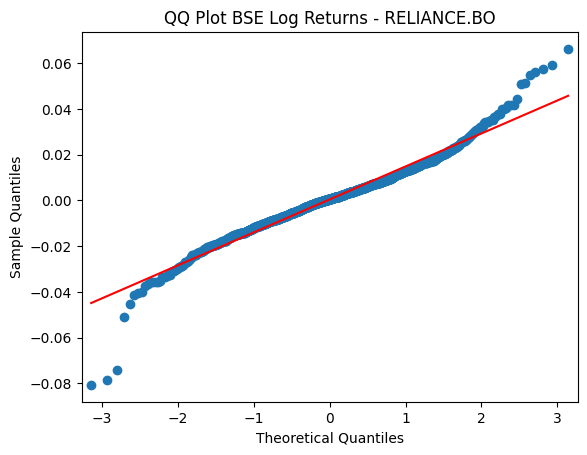

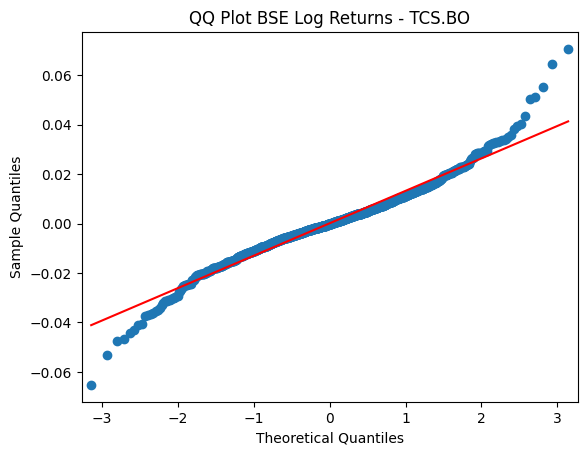

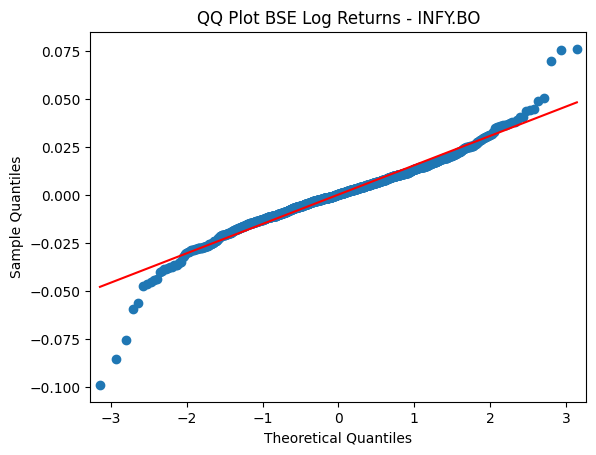

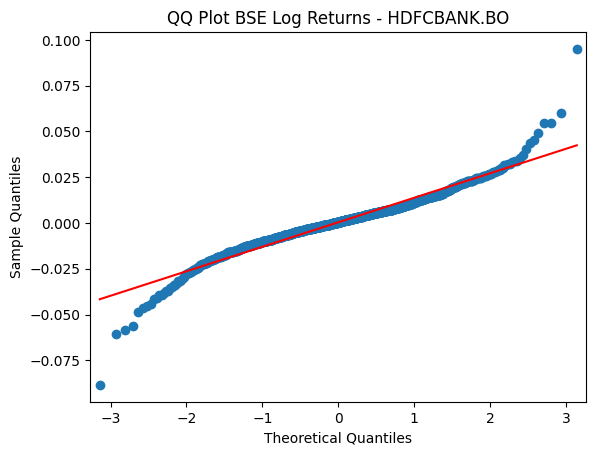

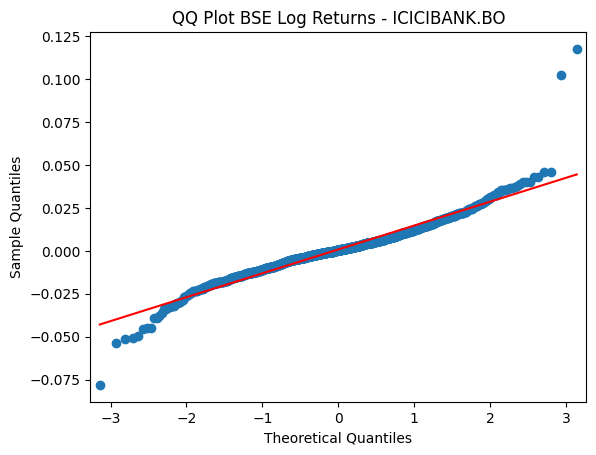

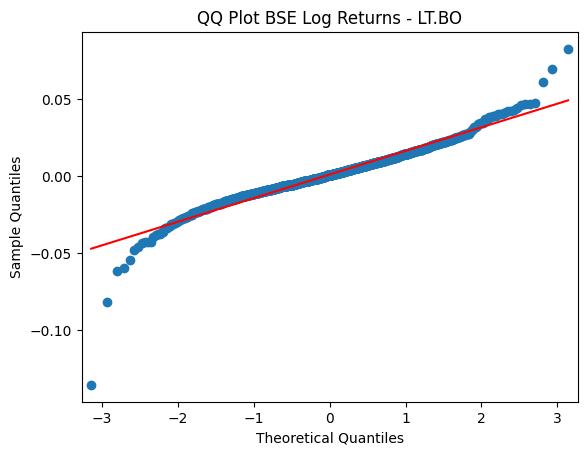

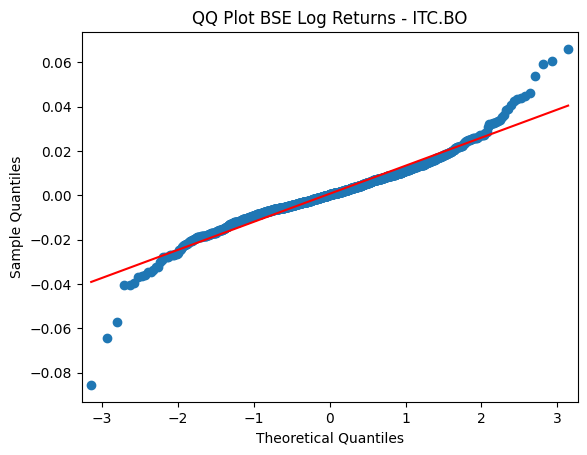

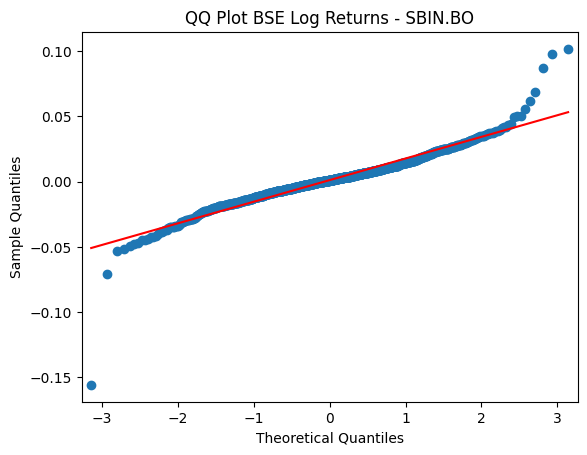

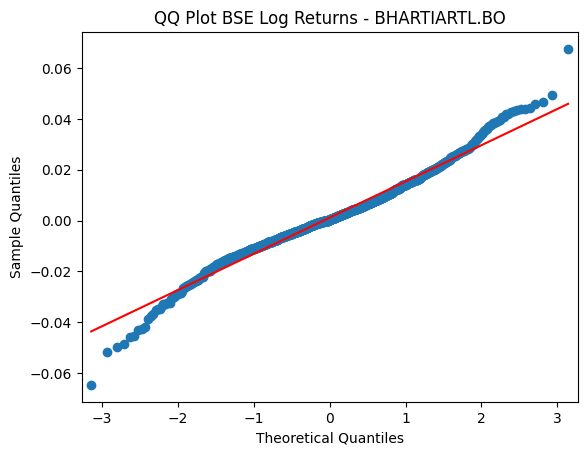

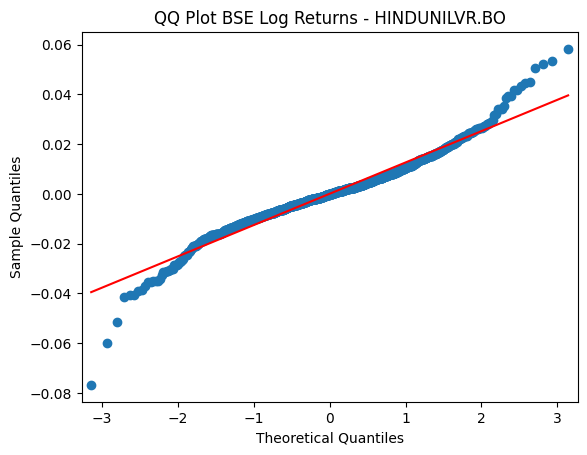

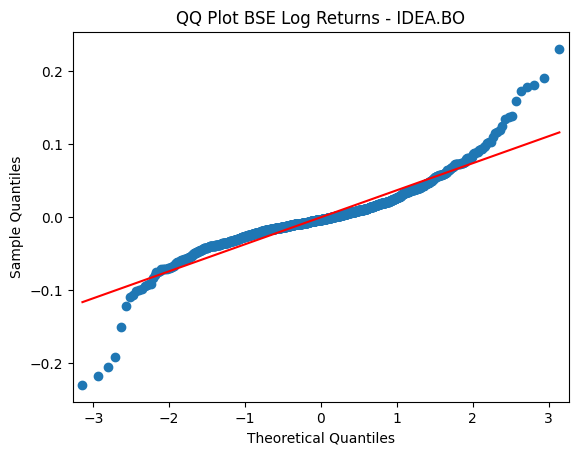

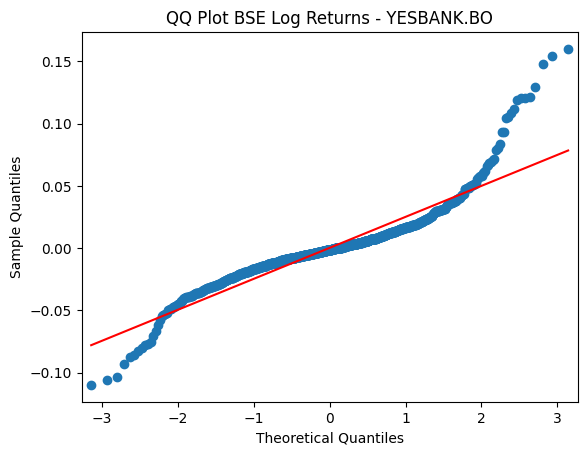

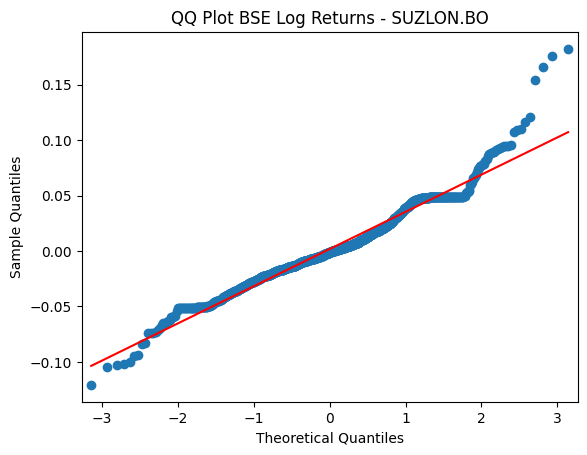

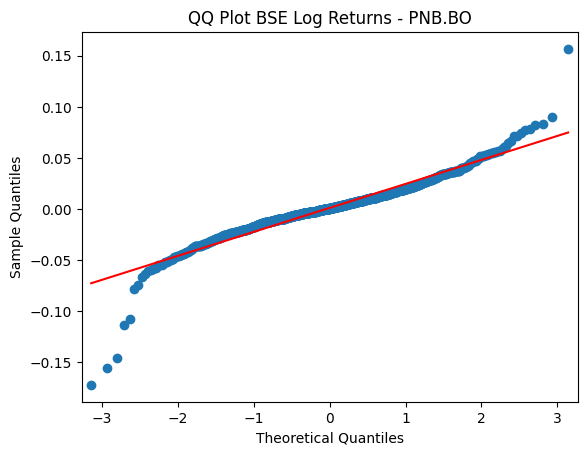

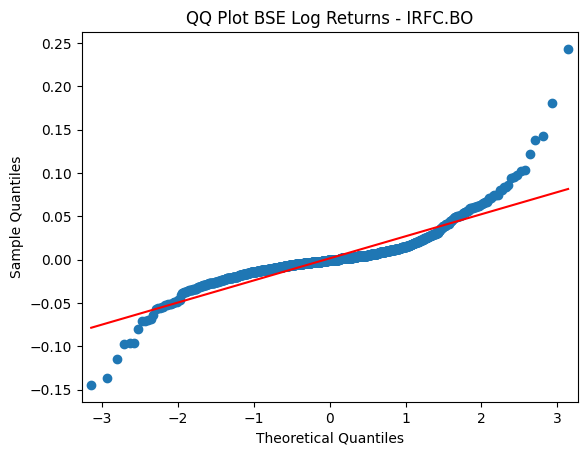

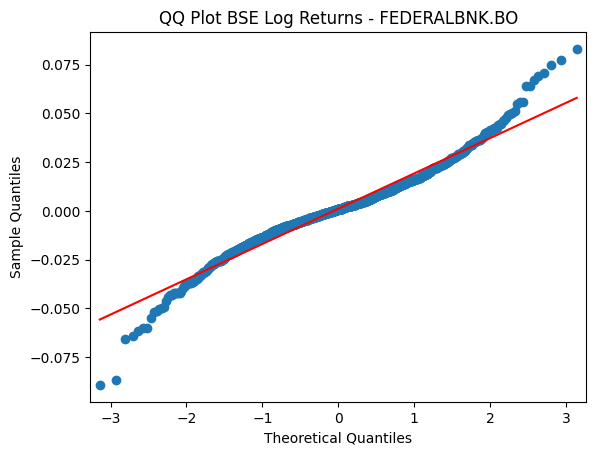

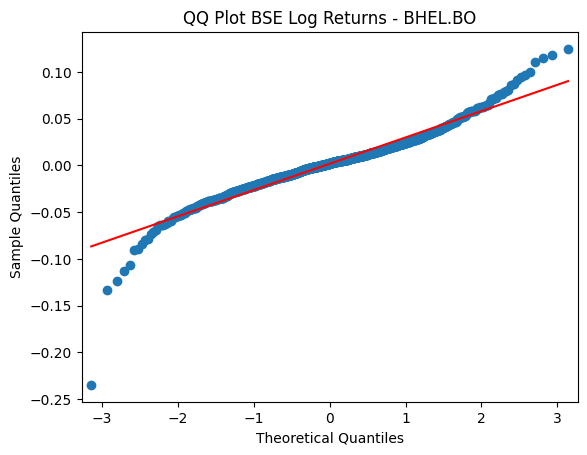

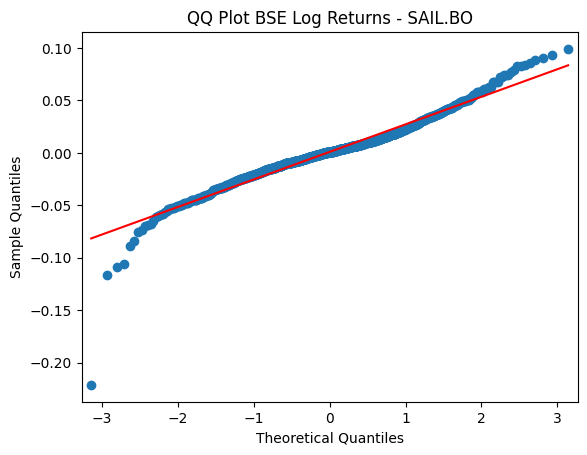

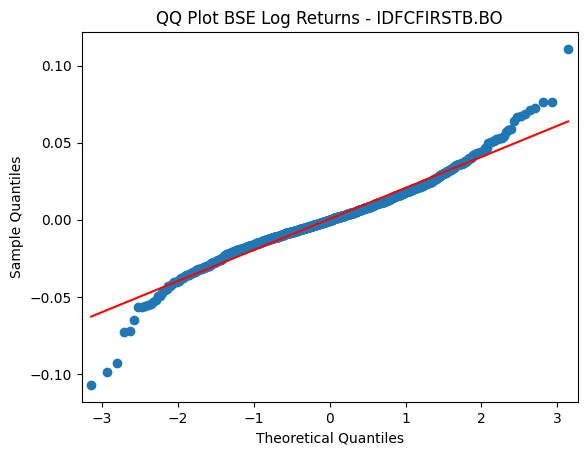

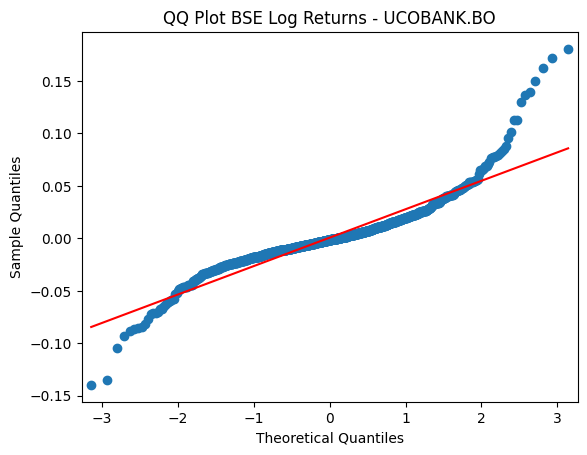


NSE LOG RETURNS KS TEST
               KS Statistic       p-value
^NSEI              0.056787  7.578574e-04
RELIANCE.NS        0.055180  1.175207e-03
TCS.NS             0.053320  1.922767e-03
INFY.NS            0.045423  1.287700e-02
HDFCBANK.NS        0.065788  5.138902e-05
ICICIBANK.NS       0.067329  3.114919e-05
LT.NS              0.056167  8.990442e-04
ITC.NS             0.058687  4.437274e-04
SBIN.NS            0.071215  8.377545e-06
BHARTIARTL.NS      0.050993  3.475266e-03
HINDUNILVR.NS      0.060611  2.535089e-04
IDEA.NS            0.105839  2.636836e-12
YESBANK.NS         0.113638  4.009287e-14
SUZLON.NS          0.070099  1.230819e-05
PNB.NS             0.069866  1.332734e-05
IRFC.NS            0.151526  8.047396e-25
FEDERALBNK.NS      0.067293  3.152889e-05
BHEL.NS            0.061352  2.033866e-04
SAIL.NS            0.069866  1.332668e-05
IDFCFIRSTB.NS      0.053075  2.048900e-03
UCOBANK.NS         0.105912  2.538944e-12

BSE LOG RETURNS KS TEST
               KS Statisti

In [16]:
# MA374 Financial Engineering Lab
# Question 2: Analysis using Log Returns

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from scipy.stats import kstest, shapiro
import statsmodels.api as sm


# ---------------------------------
# Load the datasets
# ---------------------------------

nse = pd.read_csv("nsedata1.csv")
bse = pd.read_csv("bsedata1.csv")

# Convert Date column to datetime
nse['Date'] = pd.to_datetime(nse['Date'])
bse['Date'] = pd.to_datetime(bse['Date'])

# Set Date as index
nse.set_index('Date', inplace=True)
bse.set_index('Date', inplace=True)


# ---------------------------------
# Compute Log Returns
# ---------------------------------

# log return = ln(P_t / P_{t-1})

nse_log_returns = np.log(nse / nse.shift(1)).dropna()
bse_log_returns = np.log(bse / bse.shift(1)).dropna()


# ---------------------------------
# Helper Functions
# ---------------------------------

def descriptive_statistics(returns):

    stats = pd.DataFrame(columns=[
        "Mean",
        "Standard Deviation",
        "Skewness",
        "Kurtosis"
    ])

    for col in returns.columns:

        r = returns[col].dropna()

        stats.loc[col] = [
            r.mean(),
            r.std(),
            skew(r),
            kurtosis(r)
        ]

    return stats


def ks_test(returns):

    results = {}

    for col in returns.columns:

        r = returns[col].dropna()

        mu = r.mean()
        sigma = r.std()

        stat, p_value = kstest(r, 'norm', args=(mu, sigma))

        results[col] = (stat, p_value)

    return pd.DataFrame(results,
                        index=["KS Statistic", "p-value"]).T


def shapiro_test(returns):

    results = {}

    for col in returns.columns:

        r = returns[col].dropna()

        stat, p_value = shapiro(r)

        results[col] = (stat, p_value)

    return pd.DataFrame(results,
                        index=["Shapiro Statistic", "p-value"]).T


def mle_estimates(returns):

    results = pd.DataFrame(columns=[
        "Mean (MLE)",
        "Variance (MLE)",
        "95% CI Lower",
        "95% CI Upper"
    ])

    for col in returns.columns:

        r = returns[col].dropna()

        n = len(r)

        mu = r.mean()
        variance = r.var()
        sigma = r.std()

        ci_lower = mu - 1.96 * sigma / np.sqrt(n)
        ci_upper = mu + 1.96 * sigma / np.sqrt(n)

        results.loc[col] = [
            mu,
            variance,
            ci_lower,
            ci_upper
        ]

    return results


# =================================
# Descriptive Statistics
# =================================

print("\n===============================")
print("NSE LOG RETURNS STATISTICS")
print("===============================")

print(descriptive_statistics(nse_log_returns))


print("\n===============================")
print("BSE LOG RETURNS STATISTICS")
print("===============================")

print(descriptive_statistics(bse_log_returns))


# =================================
# Boxplots
# =================================

plt.figure(figsize=(12,6))
sns.boxplot(data=nse_log_returns)
plt.title("Boxplot of NSE Log Returns")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=bse_log_returns)
plt.title("Boxplot of BSE Log Returns")
plt.xticks(rotation=90)
plt.show()


# =================================
# QQ Plots
# =================================

for col in nse_log_returns.columns:

    sm.qqplot(nse_log_returns[col], line='s')
    plt.title(f"QQ Plot NSE Log Returns - {col}")
    plt.show()


for col in bse_log_returns.columns:

    sm.qqplot(bse_log_returns[col], line='s')
    plt.title(f"QQ Plot BSE Log Returns - {col}")
    plt.show()


# =================================
# Kolmogorov-Smirnov Test
# =================================

print("\n===============================")
print("NSE LOG RETURNS KS TEST")
print("===============================")

print(ks_test(nse_log_returns))


print("\n===============================")
print("BSE LOG RETURNS KS TEST")
print("===============================")

print(ks_test(bse_log_returns))


# =================================
# Shapiro-Wilk Test
# =================================

print("\n===============================")
print("NSE LOG RETURNS SHAPIRO TEST")
print("===============================")

print(shapiro_test(nse_log_returns))


print("\n===============================")
print("BSE LOG RETURNS SHAPIRO TEST")
print("===============================")

print(shapiro_test(bse_log_returns))


# =================================
# Maximum Likelihood Estimates
# =================================

print("\n===============================")
print("NSE LOG RETURNS MLE ESTIMATES")
print("===============================")

print(mle_estimates(nse_log_returns))


print("\n===============================")
print("BSE LOG RETURNS MLE ESTIMATES")
print("===============================")

print(mle_estimates(bse_log_returns))

/tmp/ipykernel_775/1458628013.py:123: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  nse_monthly = nse.resample('M').last()
/tmp/ipykernel_775/1458628013.py:124: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  bse_monthly = bse.resample('M').last()



WEEKLY RETURNS ANALYSIS

NSE Weekly Descriptive Statistics
                   Mean  Standard Deviation  Skewness   Kurtosis
^NSEI          0.002679            0.018698  0.116635   1.863309
RELIANCE.NS    0.002820            0.029665  0.109721   0.351061
TCS.NS         0.001039            0.029652 -0.445196   0.373492
INFY.NS        0.002095            0.033102 -0.469137   0.326553
HDFCBANK.NS    0.001970            0.027674  0.334388   3.575725
ICICIBANK.NS   0.004106            0.028701  0.649263   1.695784
LT.NS          0.005065            0.032729  0.157384   0.548766
ITC.NS         0.004033            0.029846  0.790512   3.052070
SBIN.NS        0.005879            0.039983  3.590572  33.141437
BHARTIARTL.NS  0.005771            0.028722  0.141980   0.191911
HINDUNILVR.NS  0.000781            0.028826  0.505730   1.240541
IDEA.NS        0.003323            0.079379  0.804717   2.110417
YESBANK.NS     0.002694            0.056311  1.474331   5.639910
SUZLON.NS      0.011559       

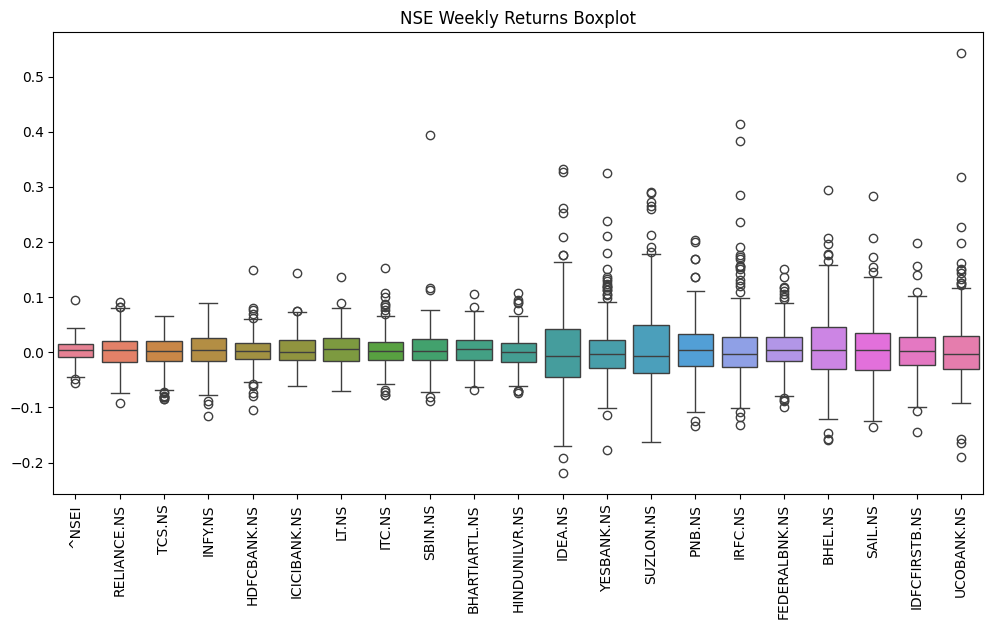

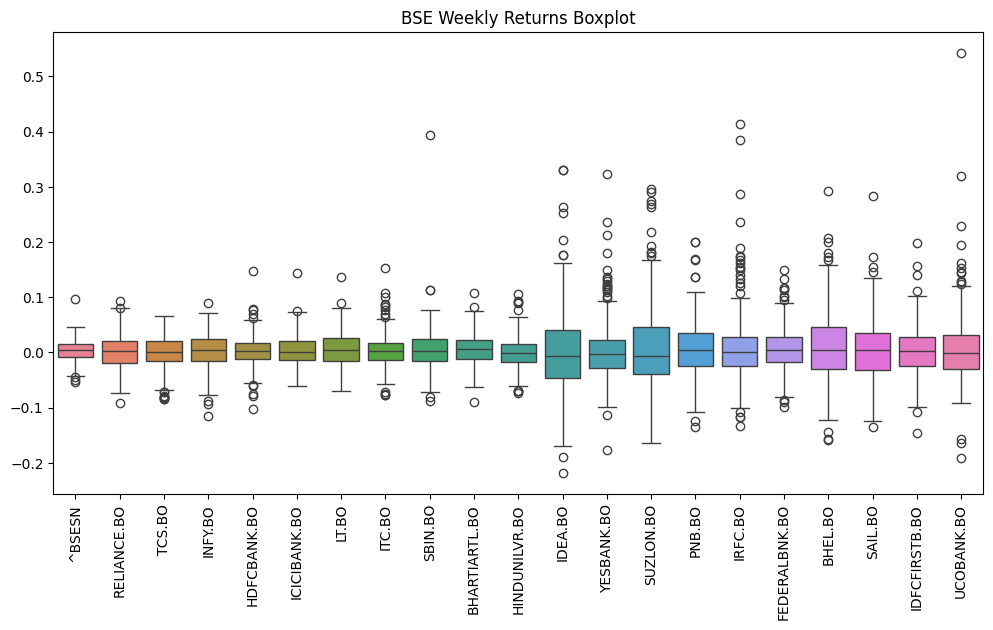

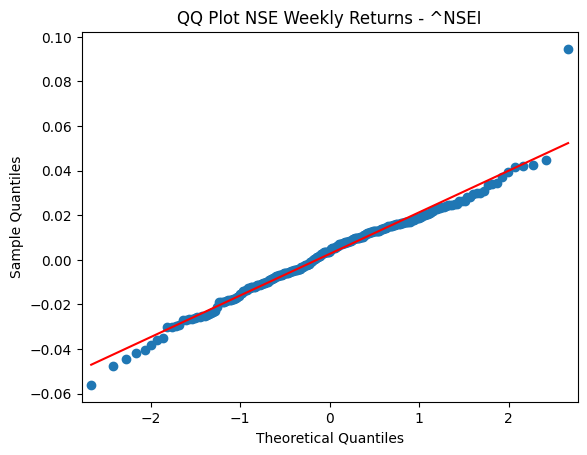

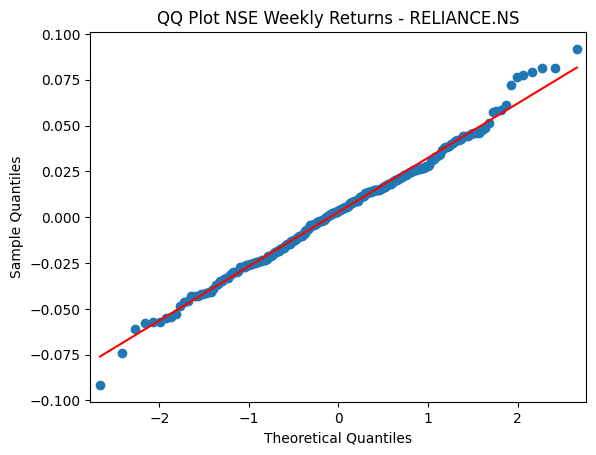

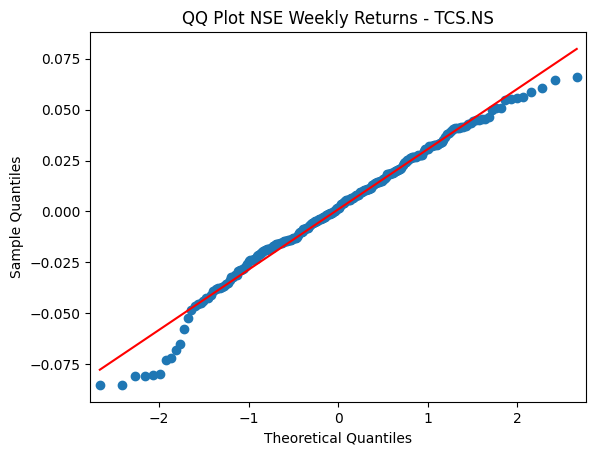

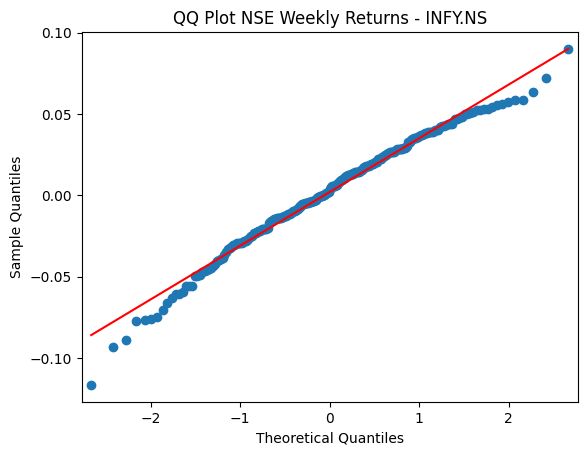

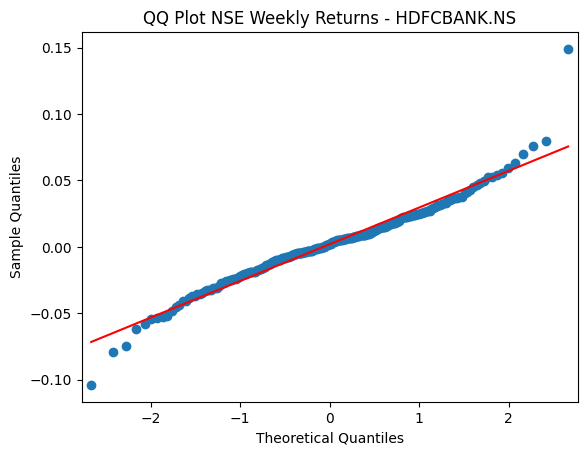

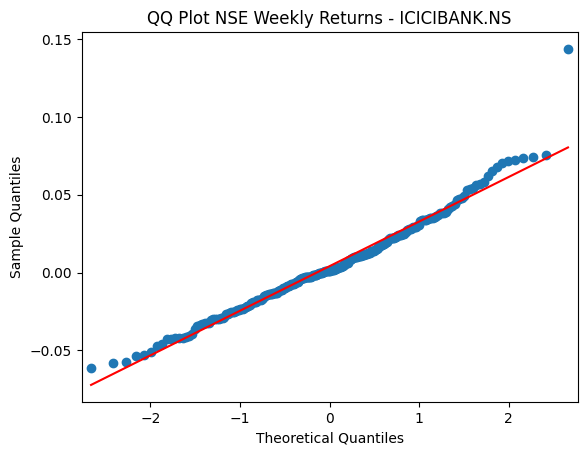

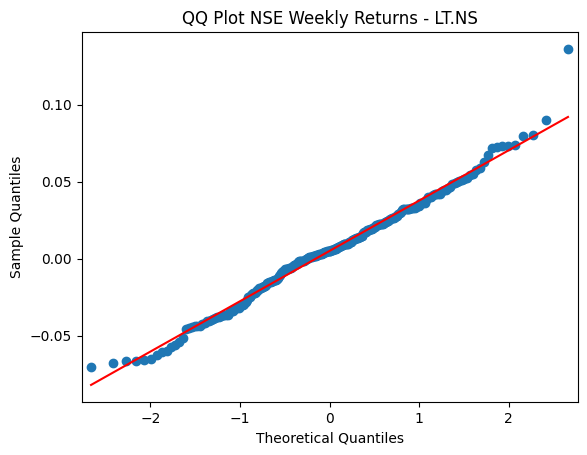

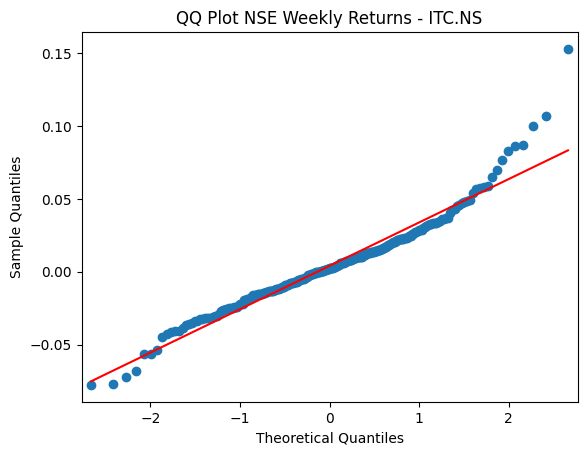

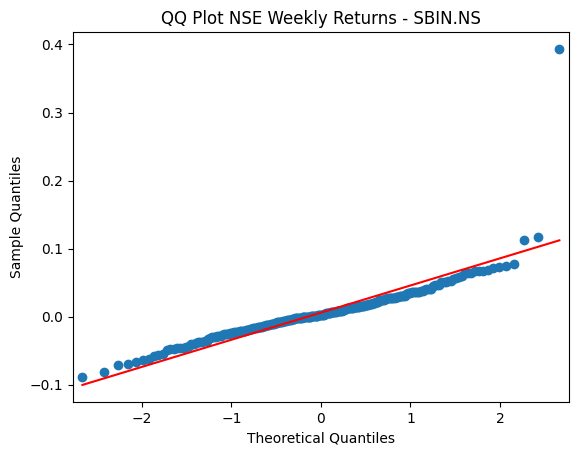

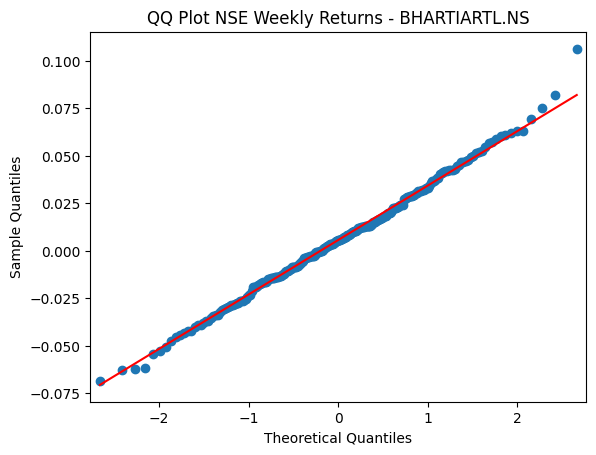

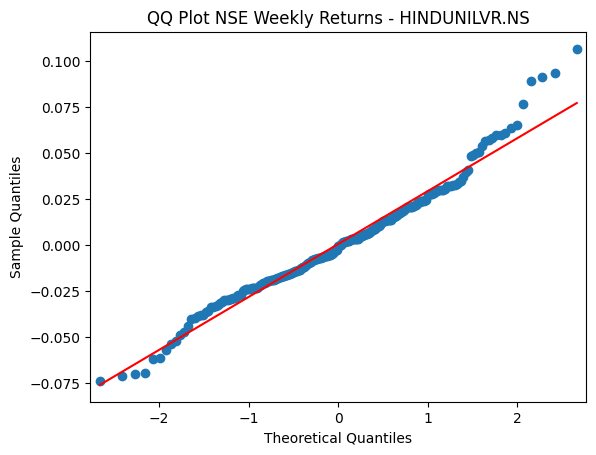

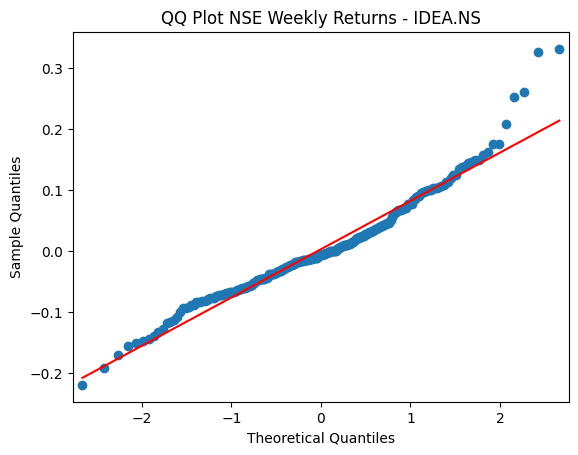

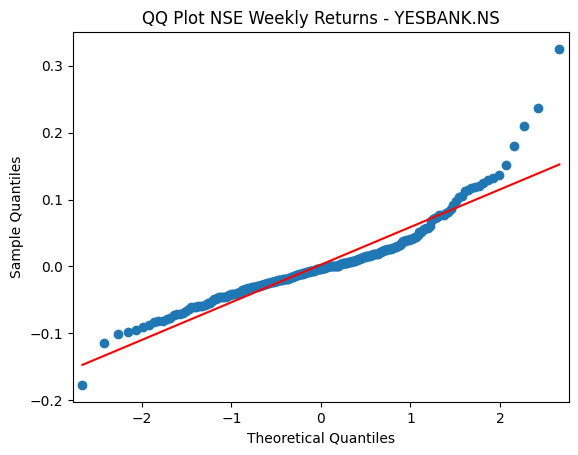

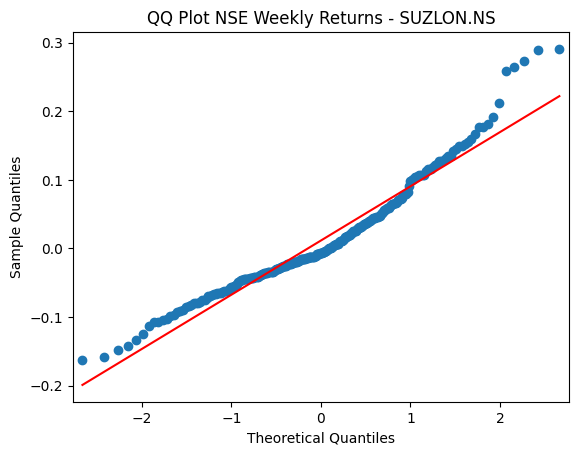

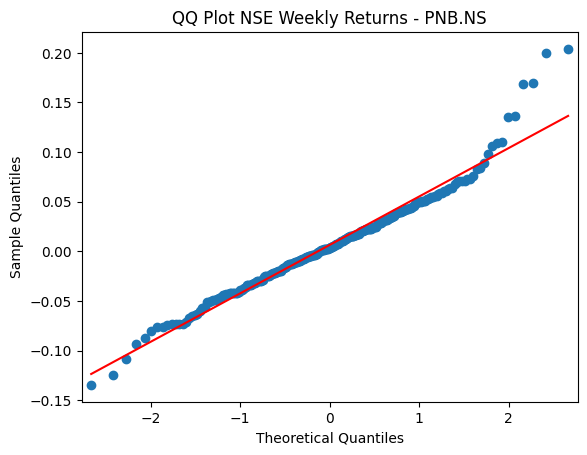

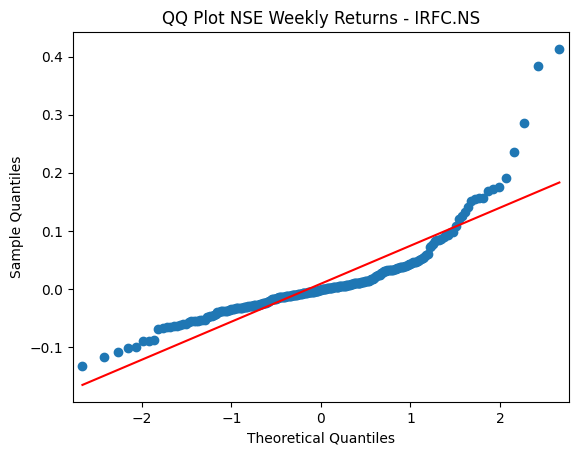

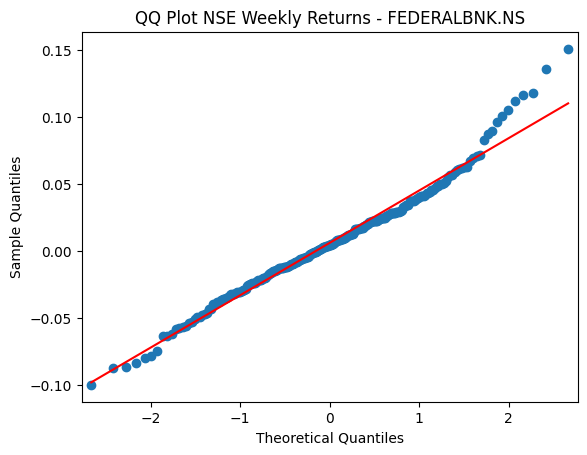

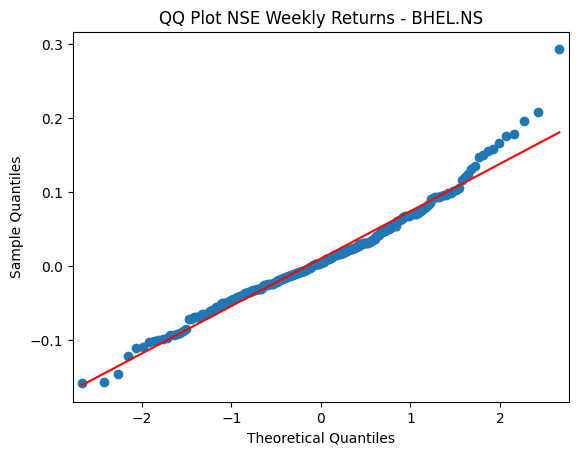

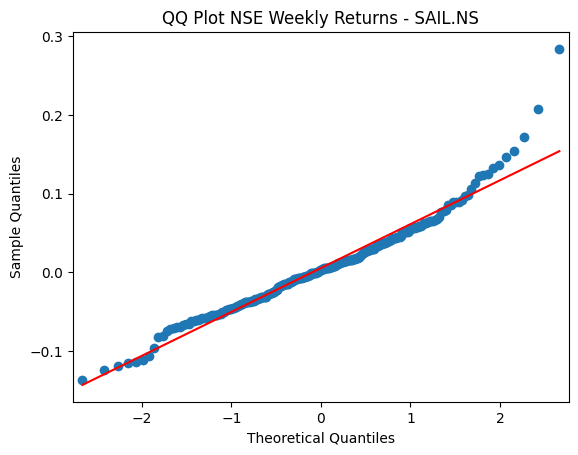

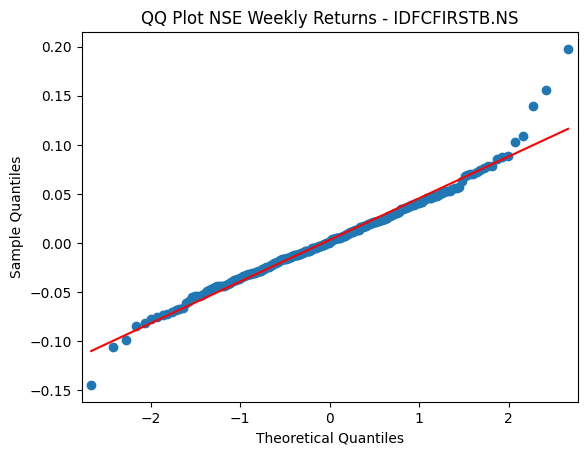

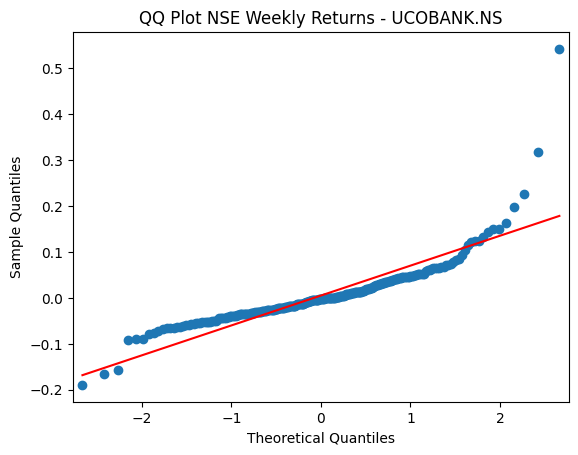

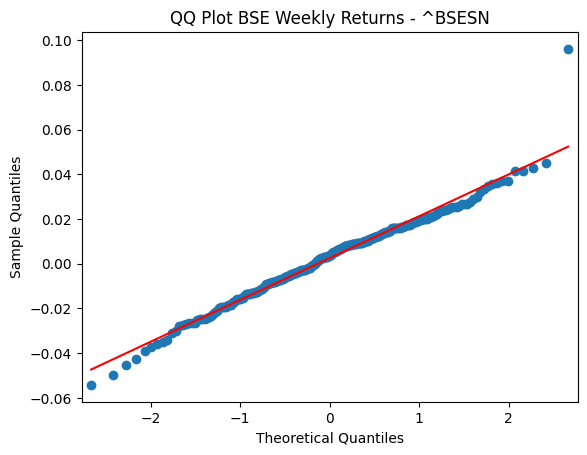

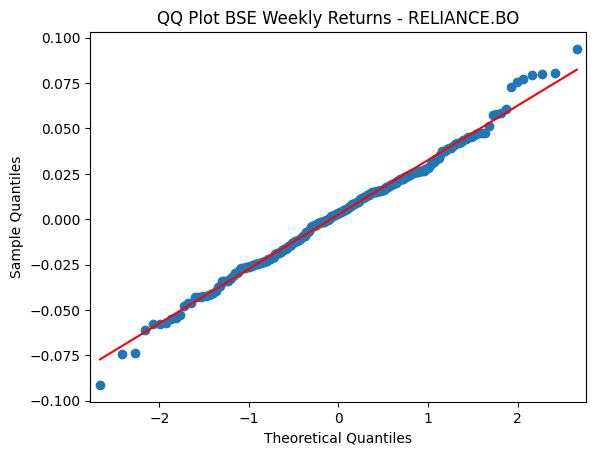

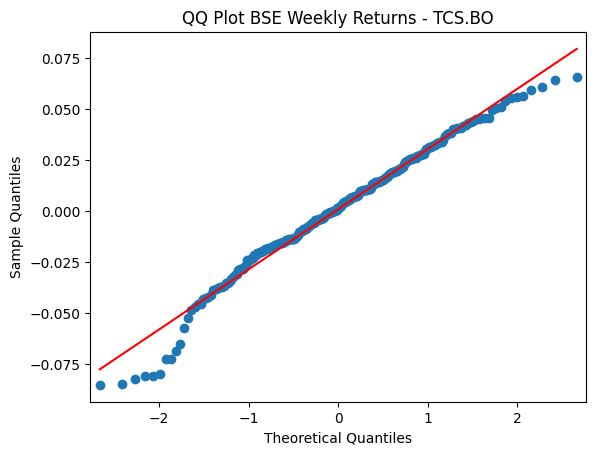

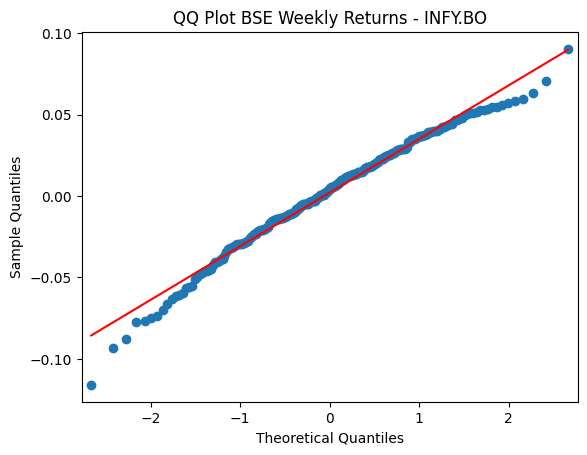

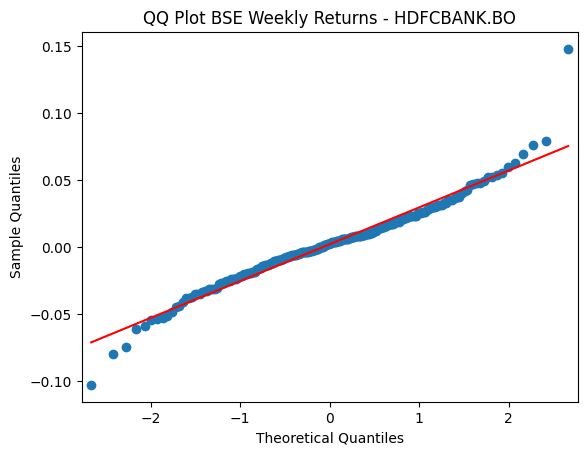

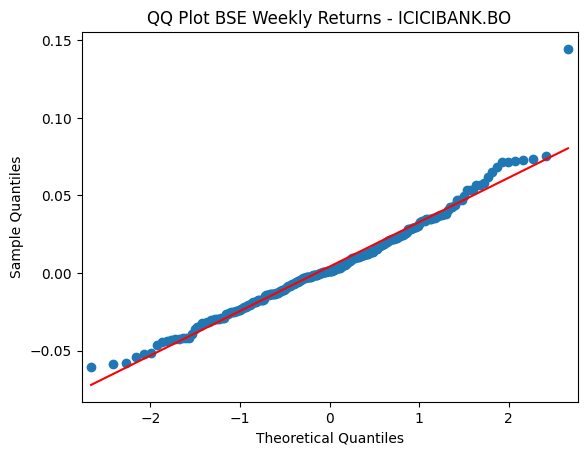

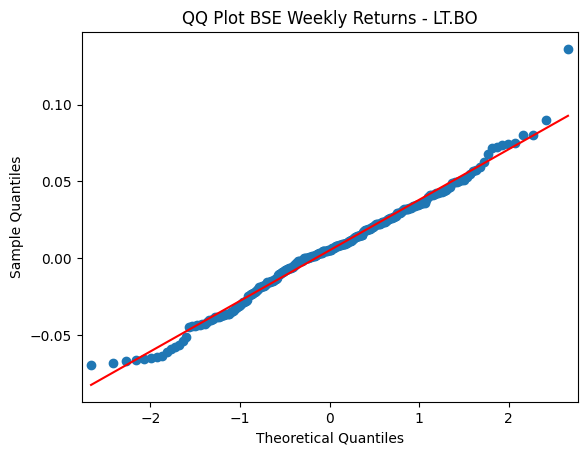

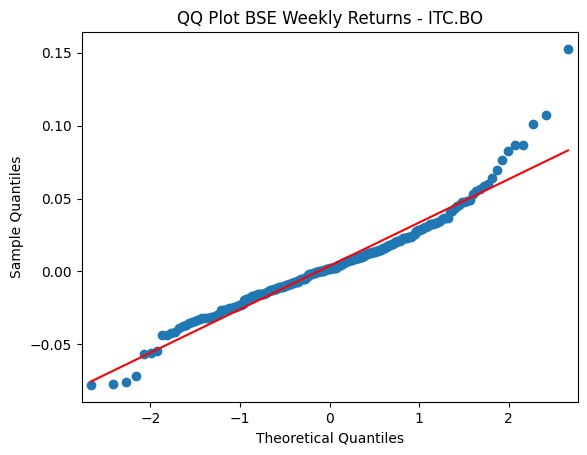

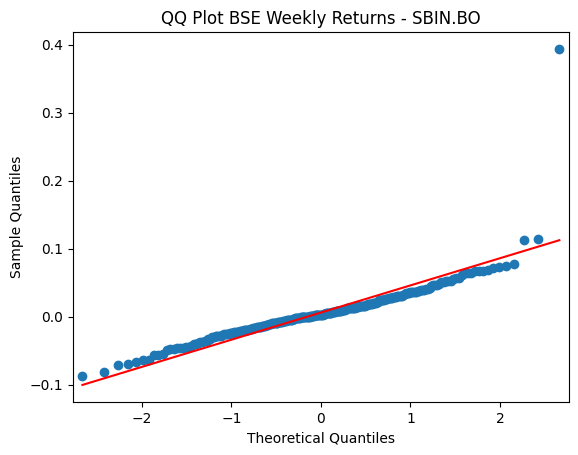

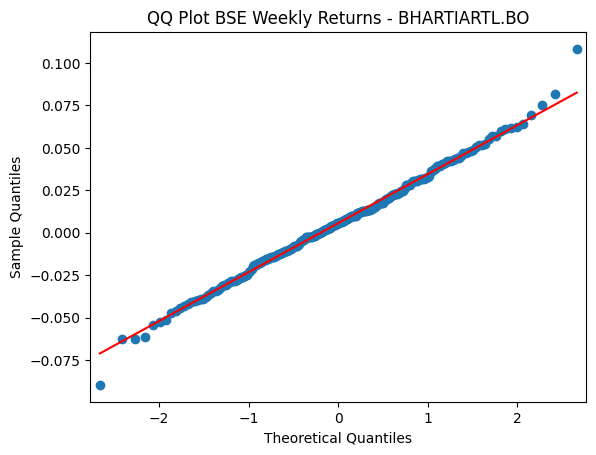

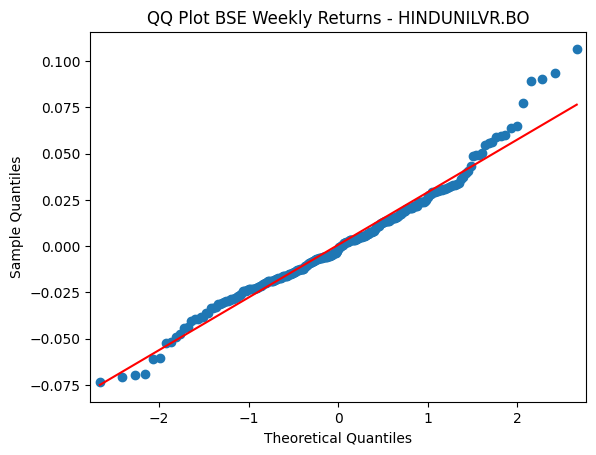

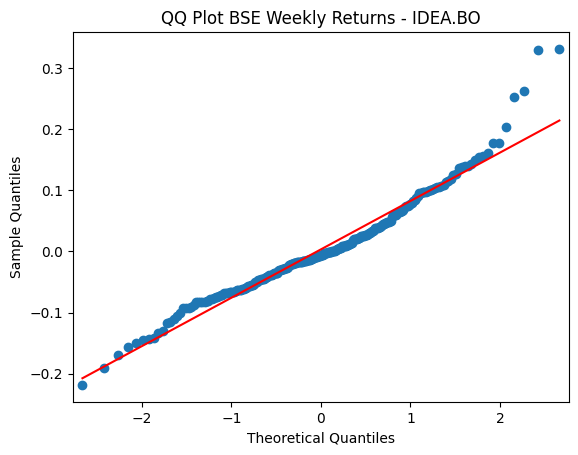

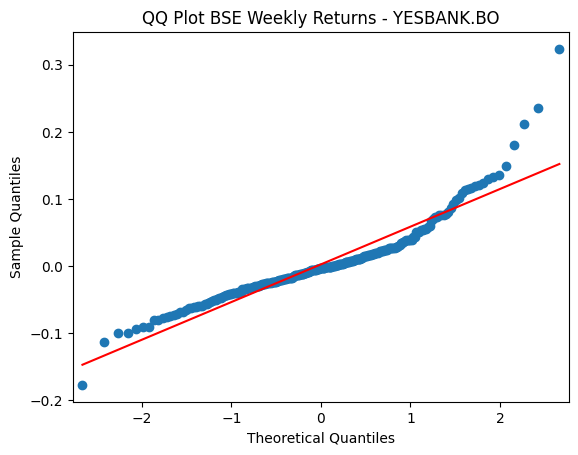

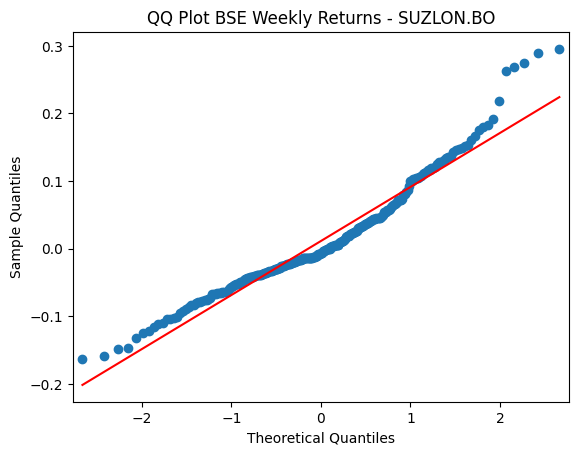

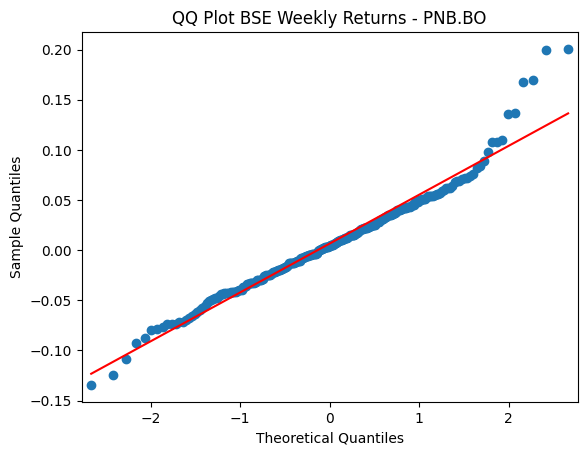

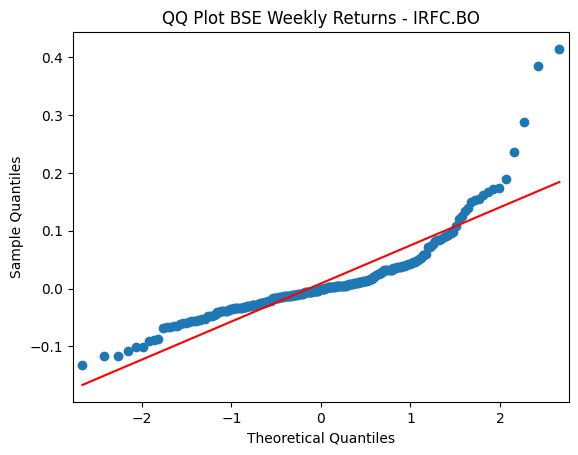

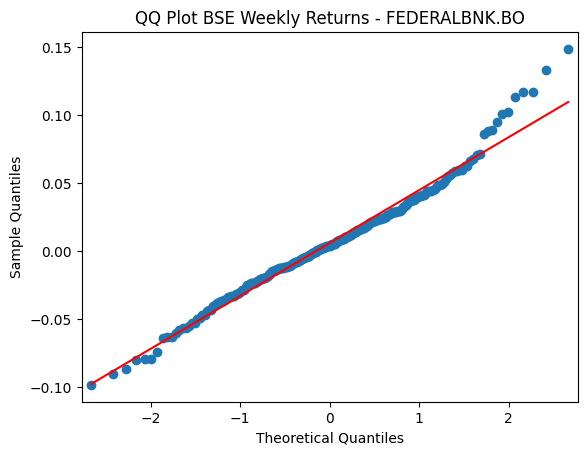

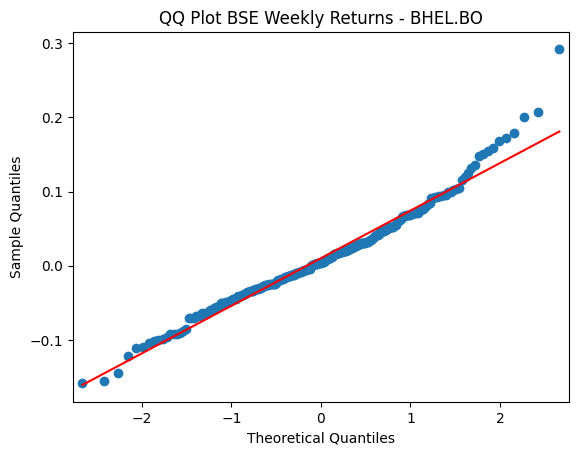

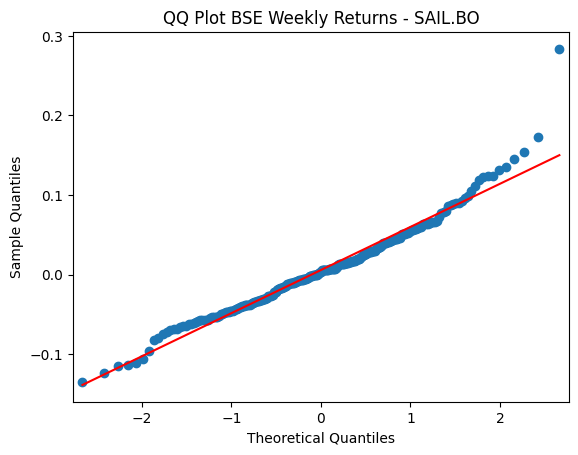

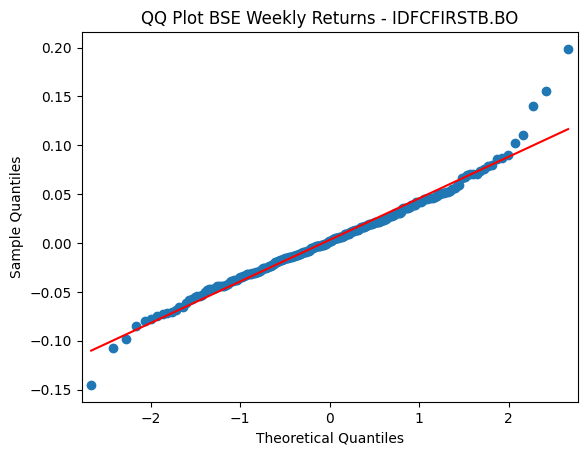

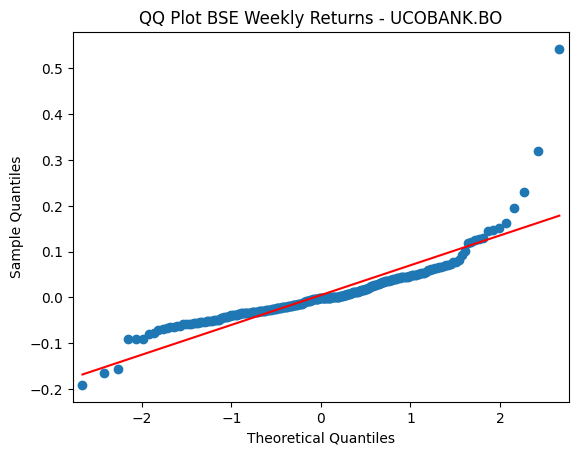


NSE Weekly KS Test
               KS Statistic       p-value
^NSEI              0.049253  5.445777e-01
RELIANCE.NS        0.043954  6.865982e-01
TCS.NS             0.046459  6.188901e-01
INFY.NS            0.043731  6.926188e-01
HDFCBANK.NS        0.059865  3.035519e-01
ICICIBANK.NS       0.060136  2.985130e-01
LT.NS              0.054264  4.207224e-01
ITC.NS             0.071527  1.373386e-01
SBIN.NS            0.095621  1.697668e-02
BHARTIARTL.NS      0.037705  8.445832e-01
HINDUNILVR.NS      0.055219  3.990286e-01
IDEA.NS            0.087304  3.739655e-02
YESBANK.NS         0.124559  6.200745e-04
SUZLON.NS          0.106620  5.348452e-03
PNB.NS             0.052464  4.634134e-01
IRFC.NS            0.176760  1.705095e-07
FEDERALBNK.NS      0.061019  2.825052e-01
BHEL.NS            0.074207  1.121402e-01
SAIL.NS            0.067817  1.795828e-01
IDFCFIRSTB.NS      0.045381  6.480348e-01
UCOBANK.NS         0.125541  5.457504e-04

BSE Weekly KS Test
               KS Statistic       p-

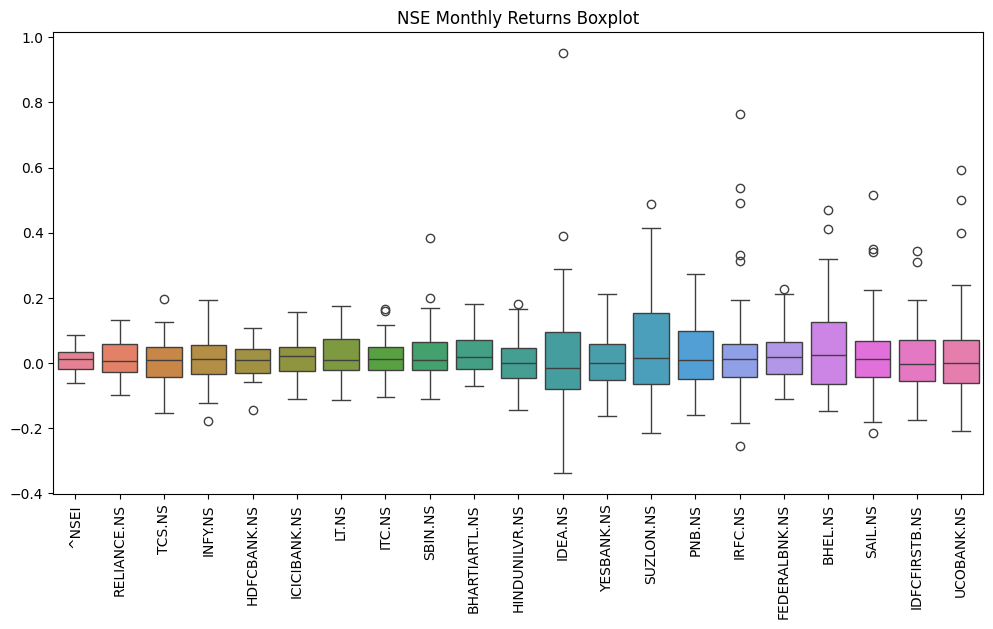

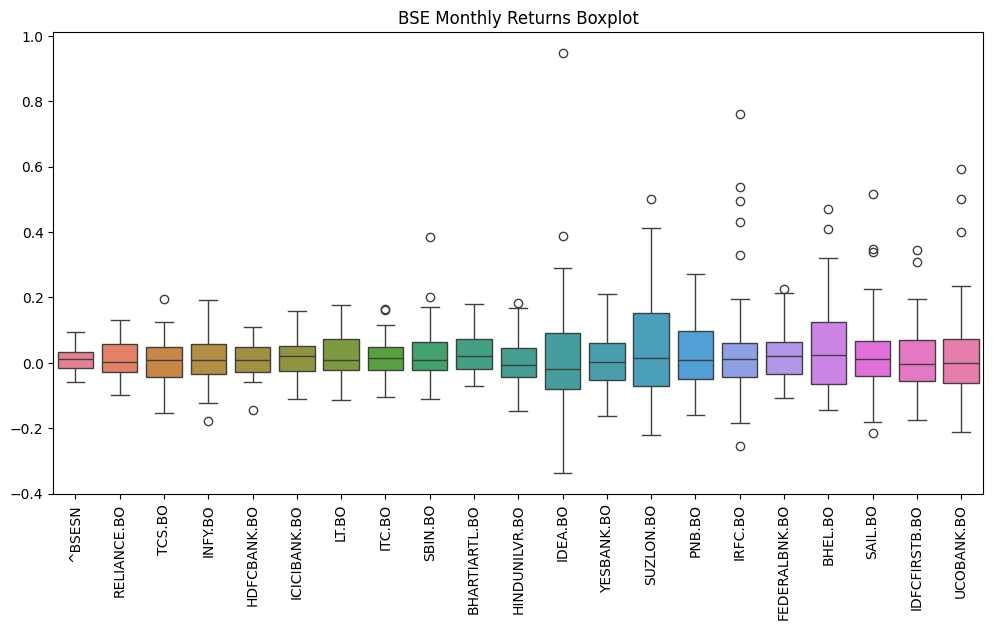

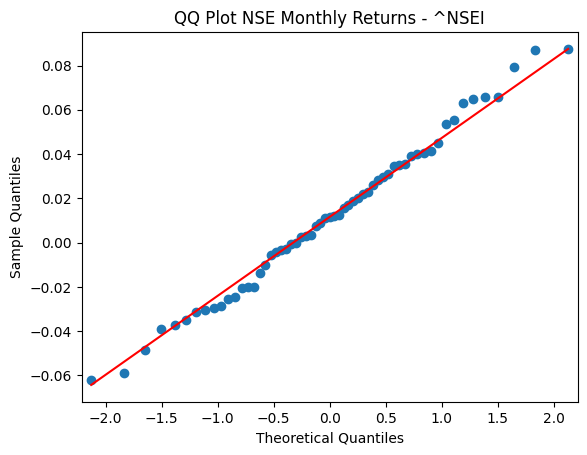

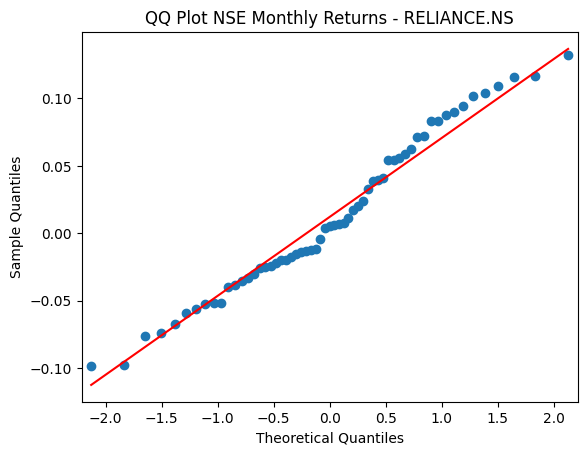

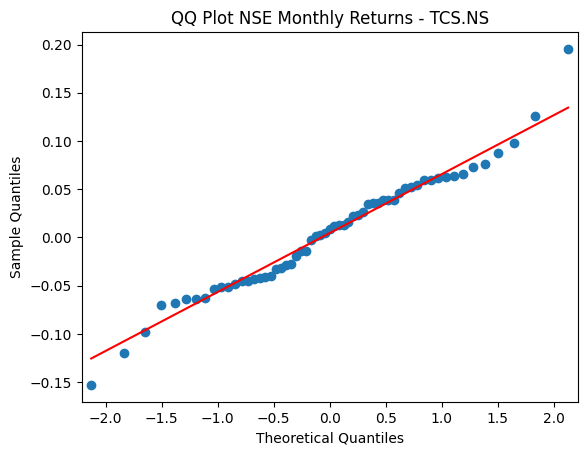

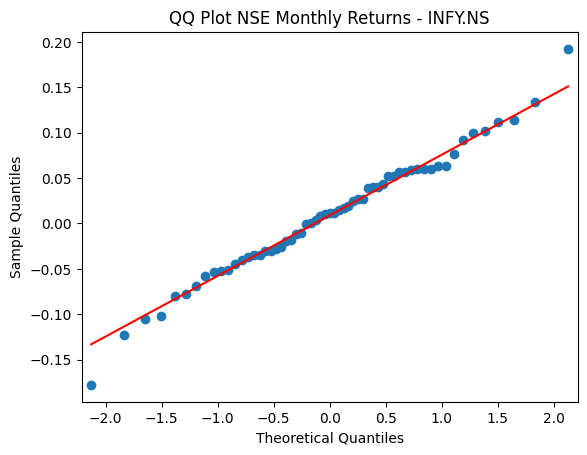

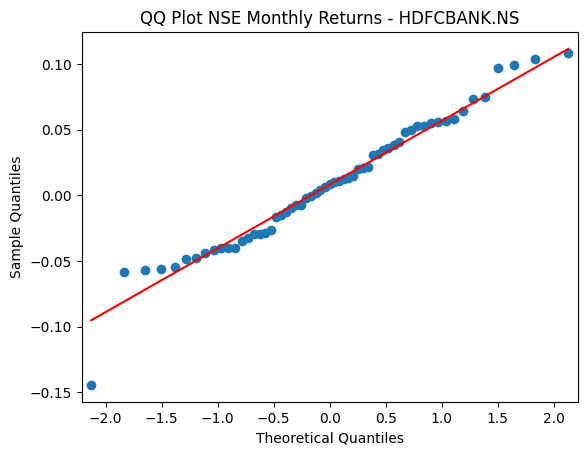

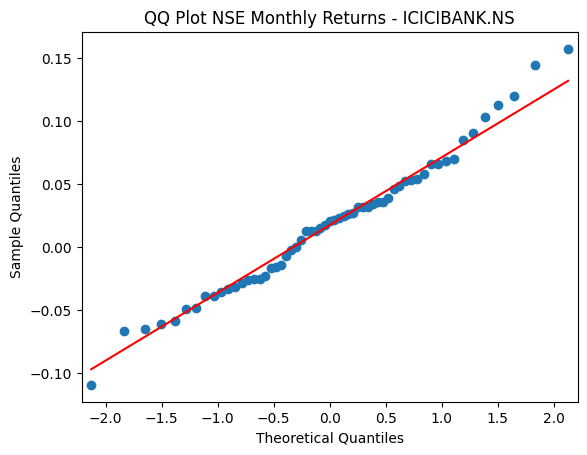

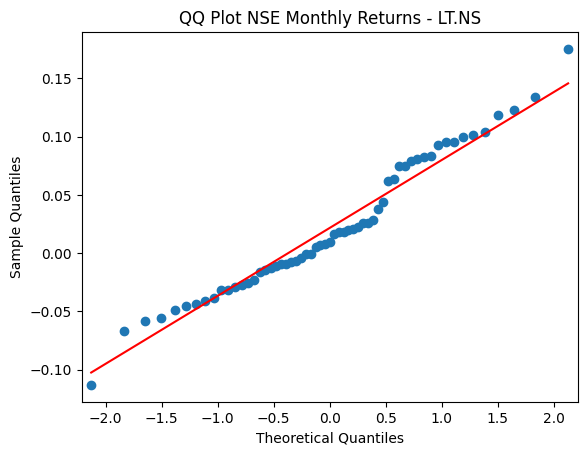

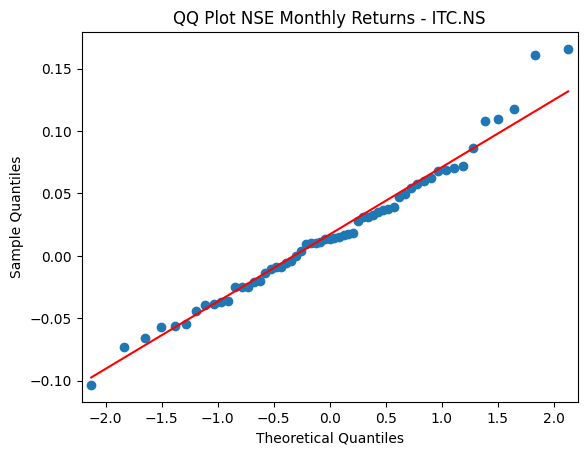

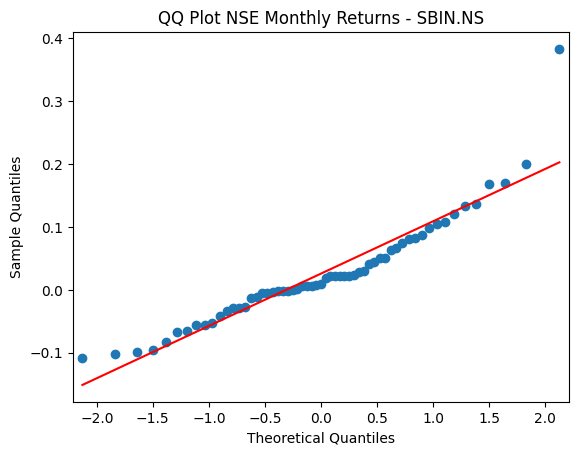

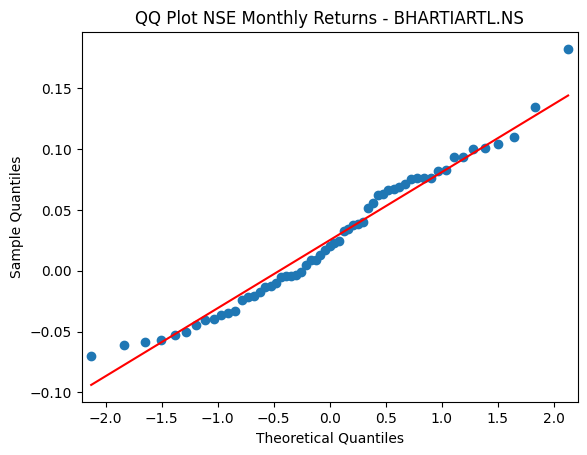

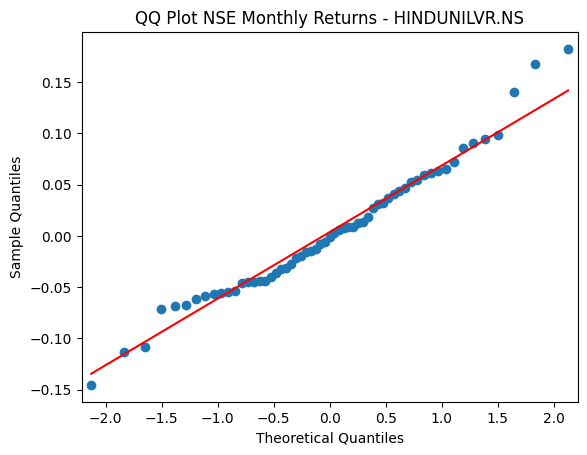

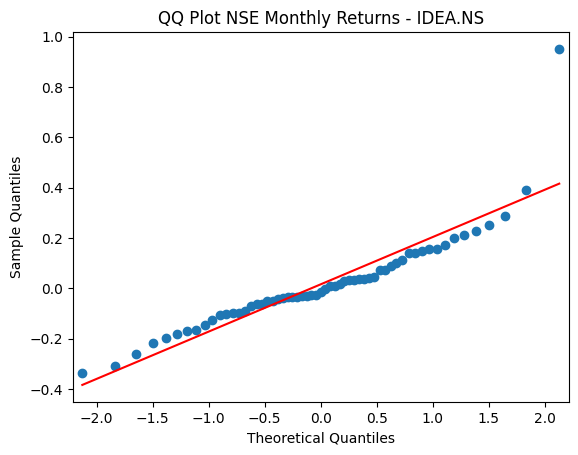

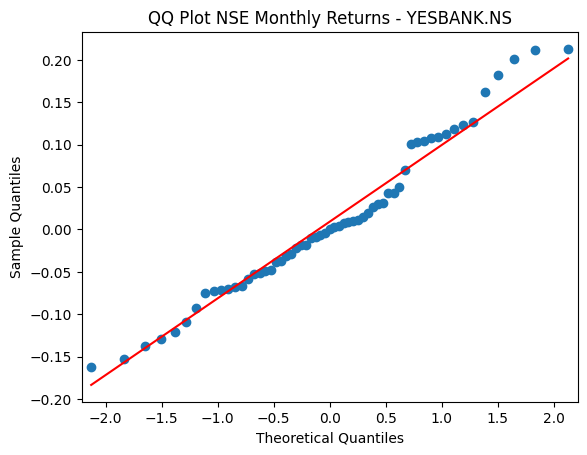

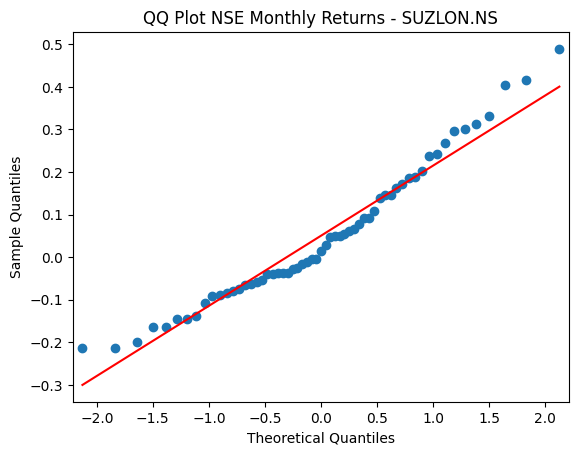

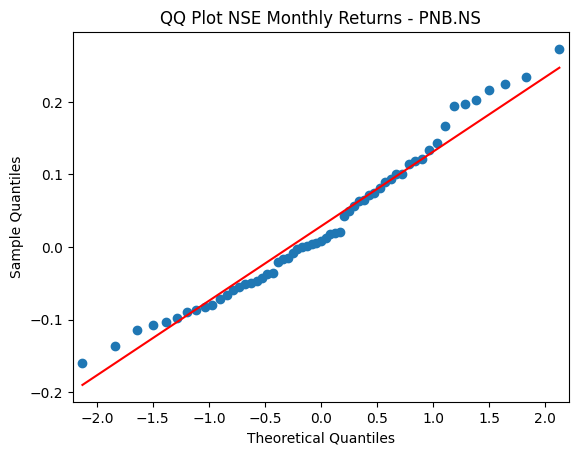

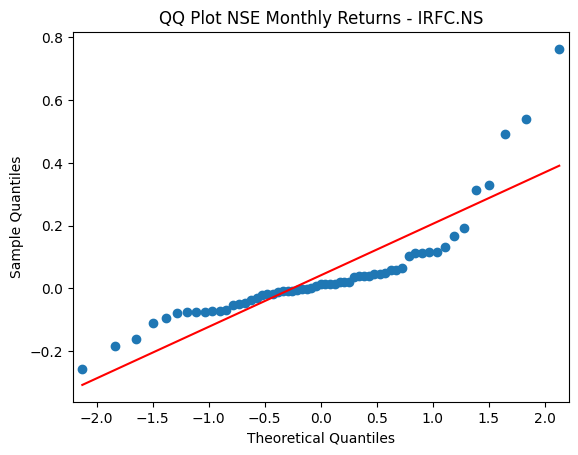

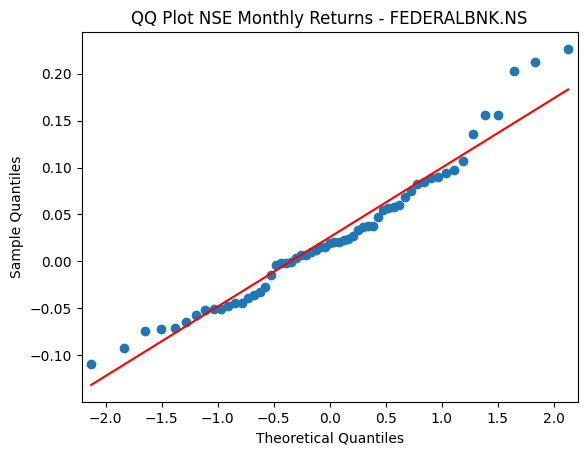

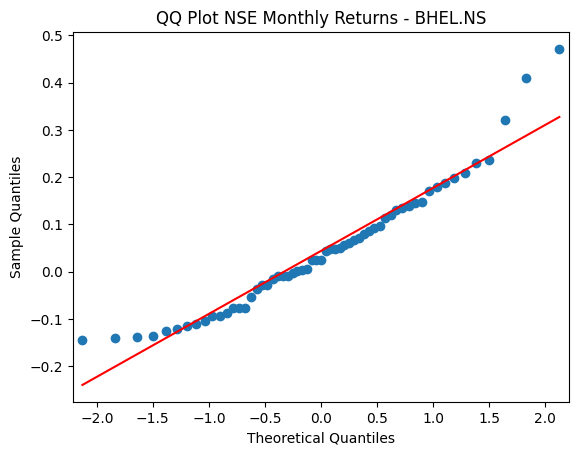

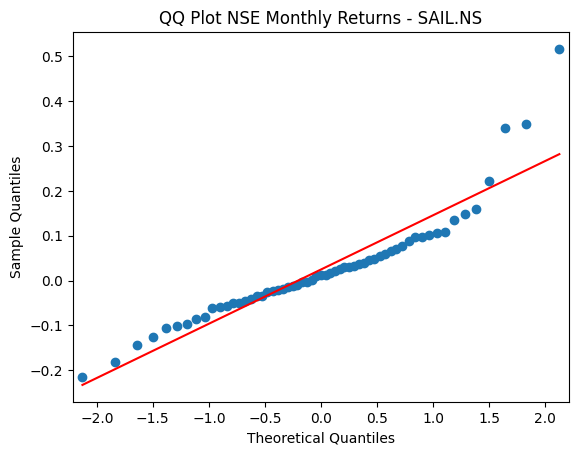

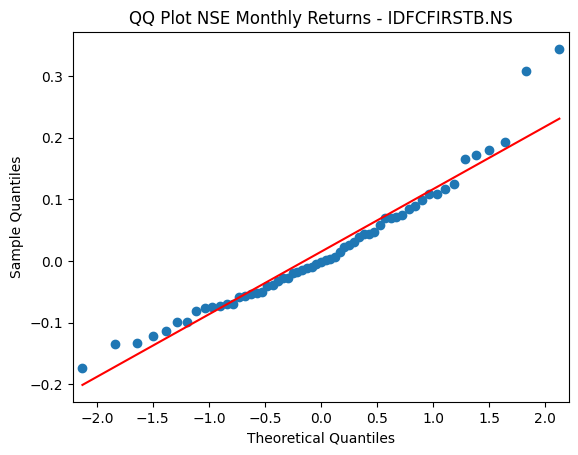

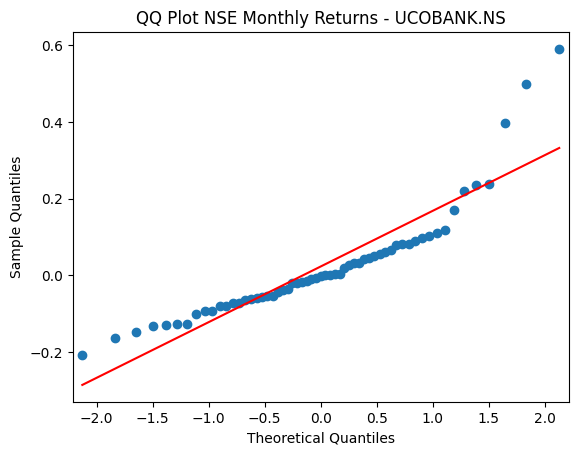

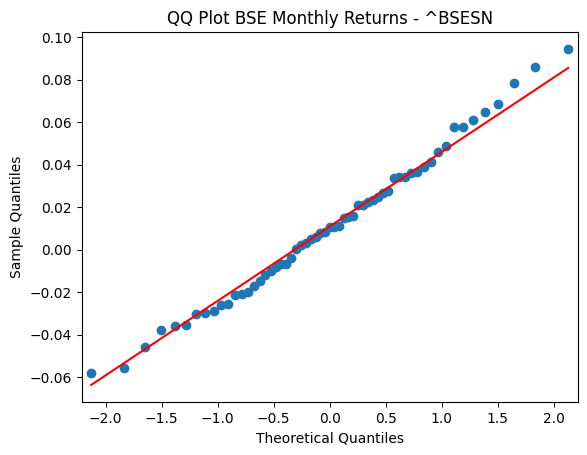

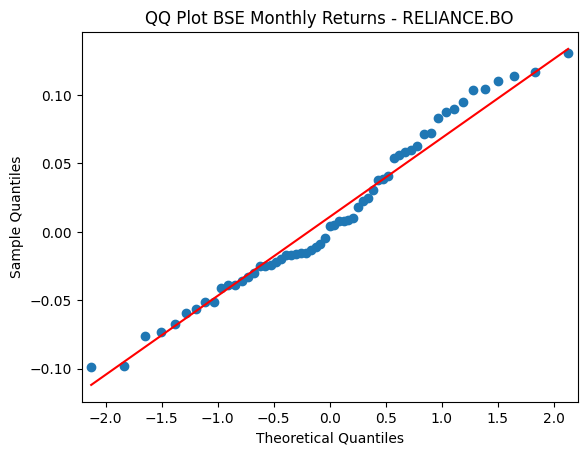

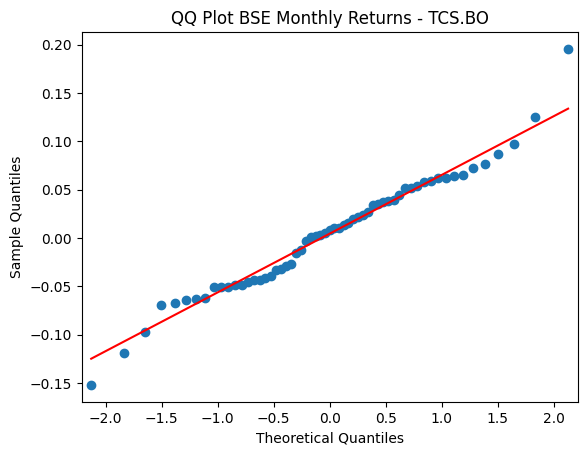

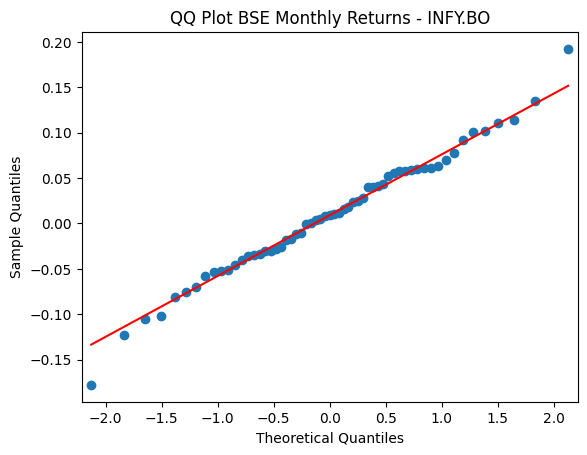

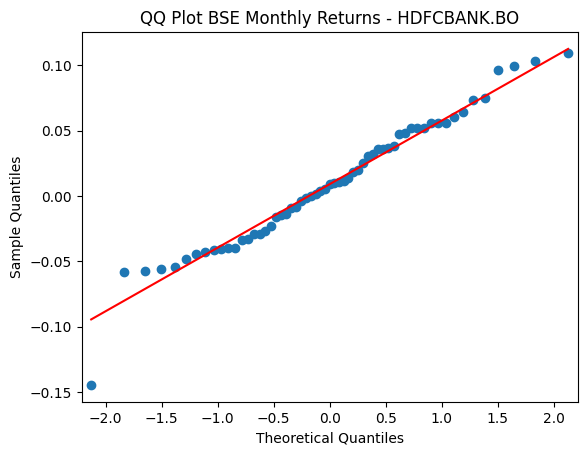

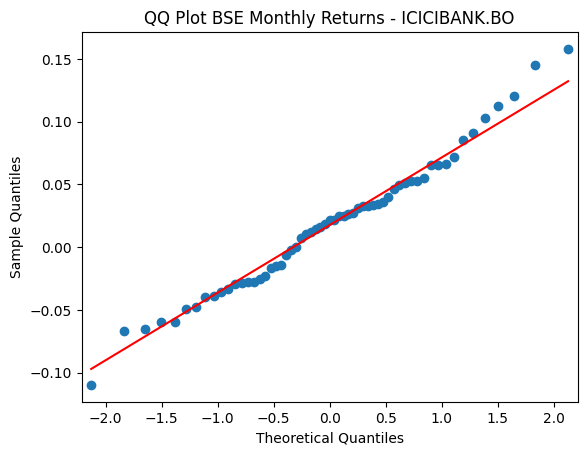

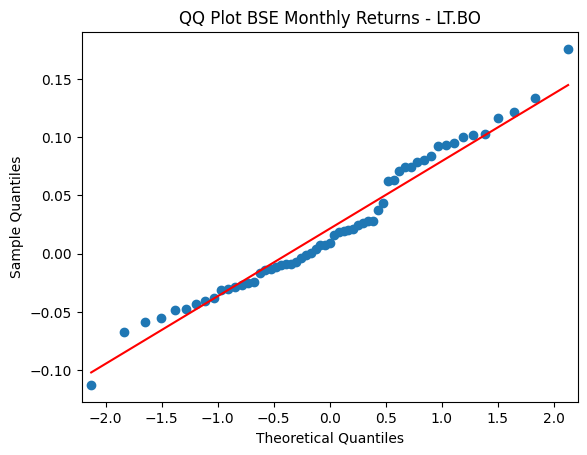

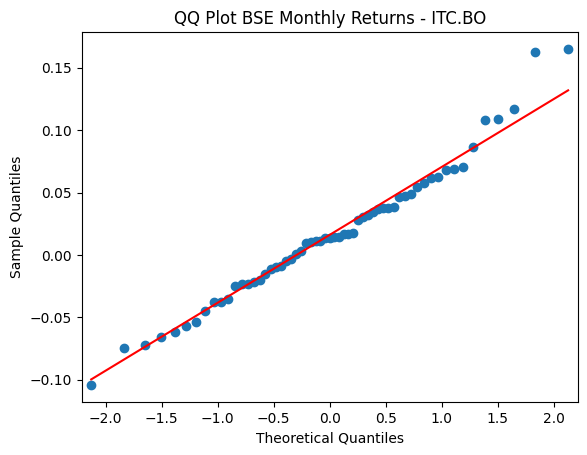

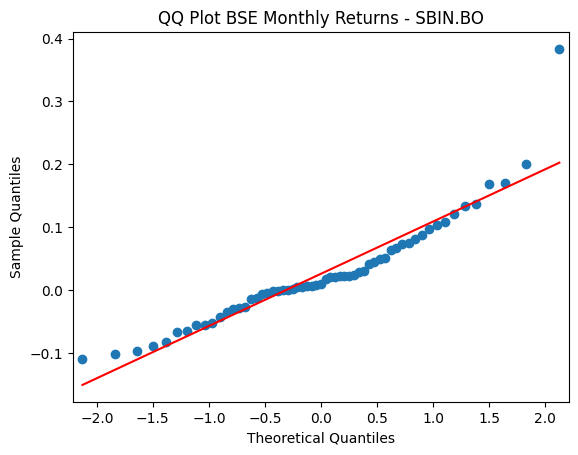

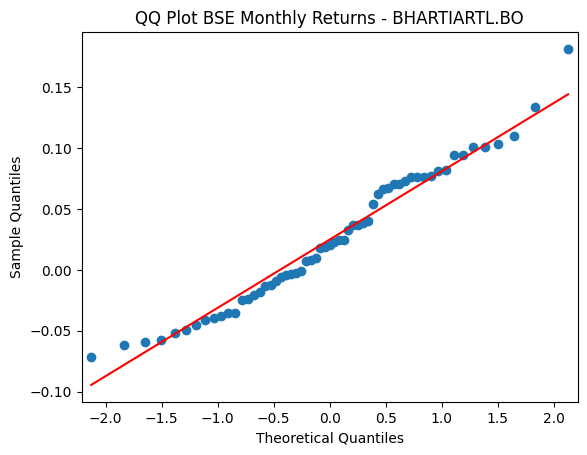

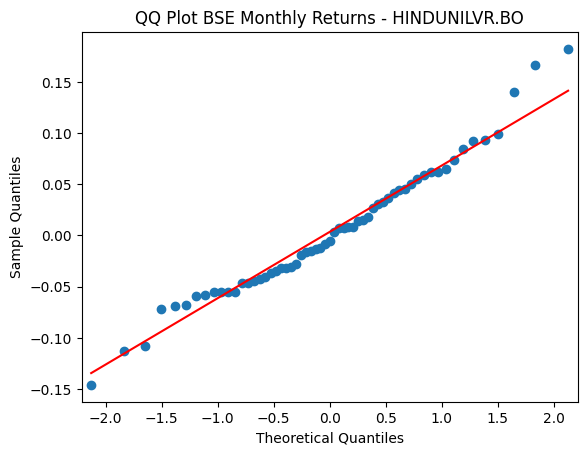

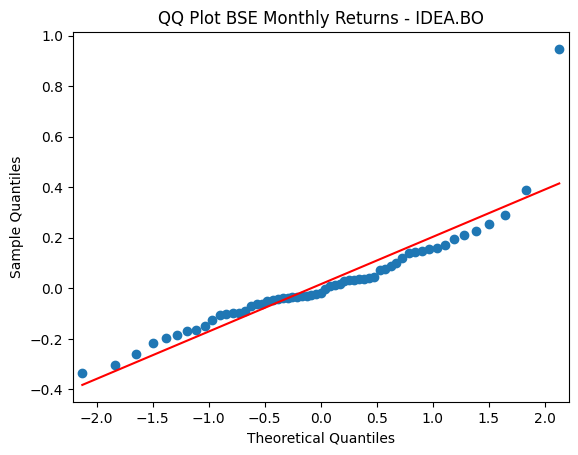

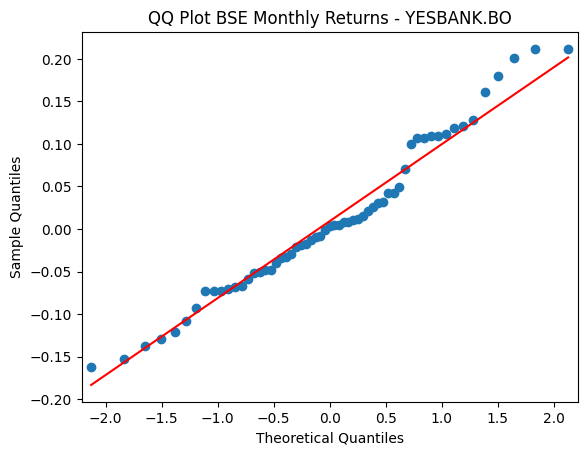

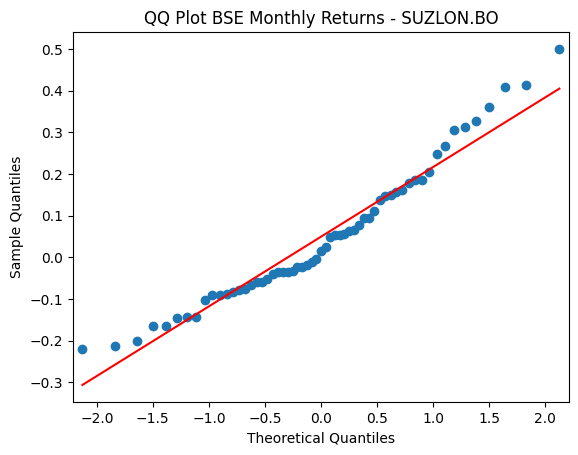

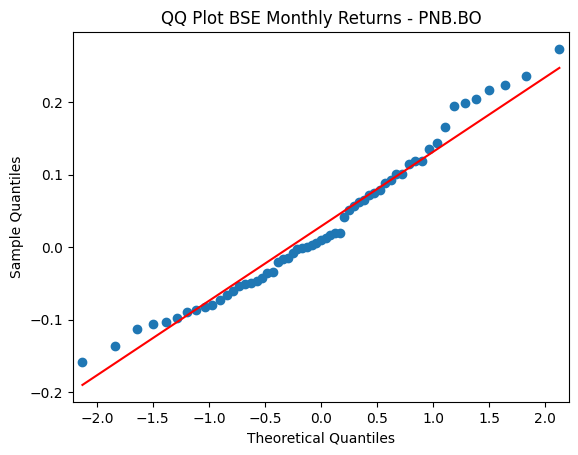

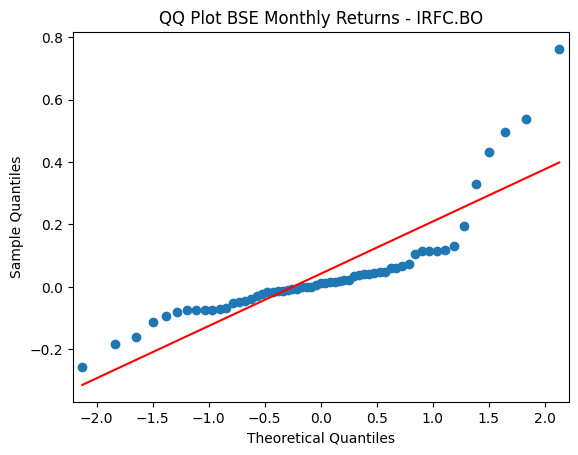

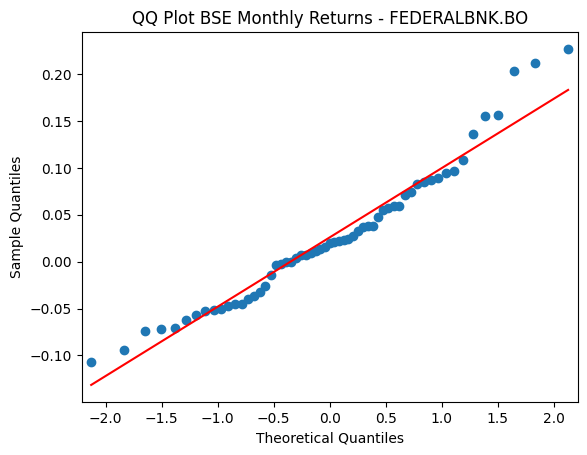

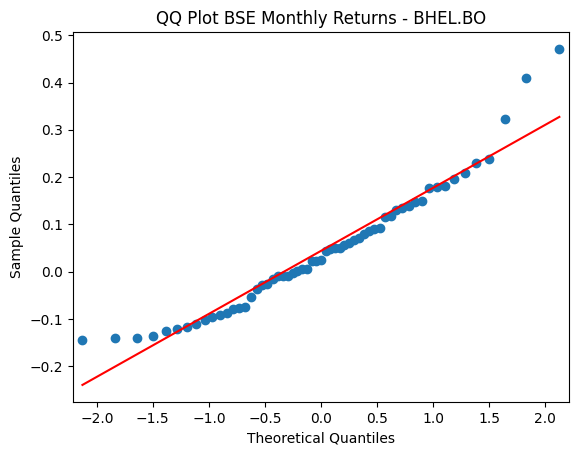

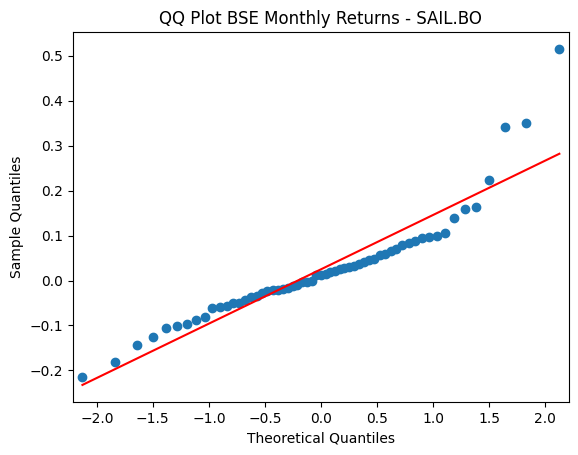

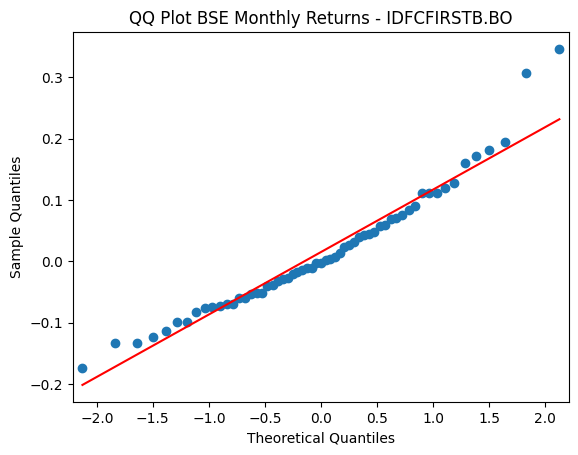

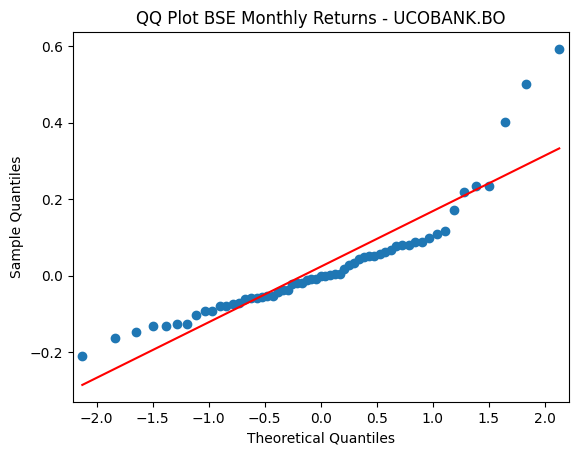


NSE Monthly KS Test
               KS Statistic   p-value
^NSEI              0.065437  0.947895
RELIANCE.NS        0.112004  0.419131
TCS.NS             0.070722  0.909132
INFY.NS            0.074035  0.879033
HDFCBANK.NS        0.070320  0.912493
ICICIBANK.NS       0.061716  0.967921
LT.NS              0.115340  0.383177
ITC.NS             0.086741  0.733529
SBIN.NS            0.140989  0.173952
BHARTIARTL.NS      0.086079  0.741888
HINDUNILVR.NS      0.074495  0.874530
IDEA.NS            0.130496  0.245287
YESBANK.NS         0.103793  0.515222
SUZLON.NS          0.121021  0.326530
PNB.NS             0.105786  0.491001
IRFC.NS            0.221536  0.005041
FEDERALBNK.NS      0.098527  0.581366
BHEL.NS            0.079249  0.824041
SAIL.NS            0.129286  0.254745
IDFCFIRSTB.NS      0.090382  0.686824
UCOBANK.NS         0.142913  0.162846

BSE Monthly KS Test
               KS Statistic   p-value
^BSESN             0.047219  0.998629
RELIANCE.BO        0.108761  0.455876
TCS.BO  

In [17]:
# MA374 Lab 07
# Question 3: Repeat analysis for weekly and monthly data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import skew, kurtosis
from scipy.stats import kstest, shapiro
import statsmodels.api as sm


# -----------------------------
# Load datasets
# -----------------------------

nse = pd.read_csv("nsedata1.csv")
bse = pd.read_csv("bsedata1.csv")

nse['Date'] = pd.to_datetime(nse['Date'])
bse['Date'] = pd.to_datetime(bse['Date'])

nse.set_index('Date', inplace=True)
bse.set_index('Date', inplace=True)


# -----------------------------
# Helper Functions
# -----------------------------

def descriptive_stats(returns):

    stats = pd.DataFrame(columns=[
        "Mean",
        "Standard Deviation",
        "Skewness",
        "Kurtosis"
    ])

    for col in returns.columns:

        r = returns[col].dropna()

        stats.loc[col] = [
            r.mean(),
            r.std(),
            skew(r),
            kurtosis(r)
        ]

    return stats


def ks_test(returns):

    results = {}

    for col in returns.columns:

        r = returns[col].dropna()

        mu = r.mean()
        sigma = r.std()

        stat, p = kstest(r, 'norm', args=(mu, sigma))

        results[col] = (stat, p)

    return pd.DataFrame(results,
        index=["KS Statistic","p-value"]).T


def shapiro_test(returns):

    results = {}

    for col in returns.columns:

        r = returns[col].dropna()

        stat, p = shapiro(r)

        results[col] = (stat, p)

    return pd.DataFrame(results,
        index=["Shapiro Statistic","p-value"]).T


def mle_estimates(returns):

    results = pd.DataFrame(columns=[
        "Mean (MLE)",
        "Variance (MLE)",
        "CI Lower",
        "CI Upper"
    ])

    for col in returns.columns:

        r = returns[col].dropna()

        n = len(r)
        mu = r.mean()
        var = r.var()
        sigma = r.std()

        ci_low = mu - 1.96 * sigma / np.sqrt(n)
        ci_high = mu + 1.96 * sigma / np.sqrt(n)

        results.loc[col] = [mu, var, ci_low, ci_high]

    return results


# -----------------------------
# Create Weekly and Monthly Prices
# -----------------------------

nse_weekly = nse.resample('W').last()
bse_weekly = bse.resample('W').last()

nse_monthly = nse.resample('M').last()
bse_monthly = bse.resample('M').last()


# -----------------------------
# Compute Returns
# -----------------------------

nse_weekly_returns = nse_weekly.pct_change().dropna()
bse_weekly_returns = bse_weekly.pct_change().dropna()

nse_monthly_returns = nse_monthly.pct_change().dropna()
bse_monthly_returns = bse_monthly.pct_change().dropna()


# =============================
# WEEKLY ANALYSIS
# =============================

print("\n==============================")
print("WEEKLY RETURNS ANALYSIS")
print("==============================")

print("\nNSE Weekly Descriptive Statistics")
print(descriptive_stats(nse_weekly_returns))

print("\nBSE Weekly Descriptive Statistics")
print(descriptive_stats(bse_weekly_returns))


# Boxplots

plt.figure(figsize=(12,6))
sns.boxplot(data=nse_weekly_returns)
plt.title("NSE Weekly Returns Boxplot")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=bse_weekly_returns)
plt.title("BSE Weekly Returns Boxplot")
plt.xticks(rotation=90)
plt.show()


# QQ Plots

for col in nse_weekly_returns.columns:

    sm.qqplot(nse_weekly_returns[col], line='s')
    plt.title(f"QQ Plot NSE Weekly Returns - {col}")
    plt.show()


for col in bse_weekly_returns.columns:

    sm.qqplot(bse_weekly_returns[col], line='s')
    plt.title(f"QQ Plot BSE Weekly Returns - {col}")
    plt.show()


# Normality Tests

print("\nNSE Weekly KS Test")
print(ks_test(nse_weekly_returns))

print("\nBSE Weekly KS Test")
print(ks_test(bse_weekly_returns))


print("\nNSE Weekly Shapiro Test")
print(shapiro_test(nse_weekly_returns))

print("\nBSE Weekly Shapiro Test")
print(shapiro_test(bse_weekly_returns))


# MLE

print("\nNSE Weekly MLE Estimates")
print(mle_estimates(nse_weekly_returns))

print("\nBSE Weekly MLE Estimates")
print(mle_estimates(bse_weekly_returns))


# =============================
# MONTHLY ANALYSIS
# =============================

print("\n==============================")
print("MONTHLY RETURNS ANALYSIS")
print("==============================")

print("\nNSE Monthly Descriptive Statistics")
print(descriptive_stats(nse_monthly_returns))

print("\nBSE Monthly Descriptive Statistics")
print(descriptive_stats(bse_monthly_returns))


# Boxplots

plt.figure(figsize=(12,6))
sns.boxplot(data=nse_monthly_returns)
plt.title("NSE Monthly Returns Boxplot")
plt.xticks(rotation=90)
plt.show()

plt.figure(figsize=(12,6))
sns.boxplot(data=bse_monthly_returns)
plt.title("BSE Monthly Returns Boxplot")
plt.xticks(rotation=90)
plt.show()


# QQ plots

for col in nse_monthly_returns.columns:

    sm.qqplot(nse_monthly_returns[col], line='s')
    plt.title(f"QQ Plot NSE Monthly Returns - {col}")
    plt.show()


for col in bse_monthly_returns.columns:

    sm.qqplot(bse_monthly_returns[col], line='s')
    plt.title(f"QQ Plot BSE Monthly Returns - {col}")
    plt.show()


# Normality tests

print("\nNSE Monthly KS Test")
print(ks_test(nse_monthly_returns))

print("\nBSE Monthly KS Test")
print(ks_test(bse_monthly_returns))


print("\nNSE Monthly Shapiro Test")
print(shapiro_test(nse_monthly_returns))

print("\nBSE Monthly Shapiro Test")
print(shapiro_test(bse_monthly_returns))


# MLE estimates

print("\nNSE Monthly MLE Estimates")
print(mle_estimates(nse_monthly_returns))

print("\nBSE Monthly MLE Estimates")
print(mle_estimates(bse_monthly_returns))